# ⚖️ Feature Scaling — A Comprehensive Visual Guide

> **Dataset:** Ames Housing Dataset | **Focus:** Understanding how 11 scaling techniques reshape, compress, and redistribute feature values

---

## 📌 Why Feature Scaling?

Most ML algorithms are **sensitive to the magnitude of feature values**.  
Without scaling:
- Features with large ranges dominate distance-based models (KNN, SVM, K-Means)
- Gradient descent converges slowly or fails entirely
- Regularisation (L1/L2) penalises features unfairly based on scale, not importance

> 🔑 **Key principle:** Scaling changes the *range* of values. Transformation changes the *shape* of the distribution.  
> Always **transform first**, then **scale**.

---

## 📋 Notebook Structure

| Section | Description |
|---|---|
| 1. Setup | Libraries, data loading, feature selection |
| 2. Scaling Reference | Quick-look table of all 11 techniques |
| 3. Apply All Scalers | One function applies every technique |
| 4. Visual Analysis | Histogram, KDE, Range, Outlier Impact, Shape |
| 5. Before & After Dashboard | Side-by-side grid for all scalers |
| 6. Statistical Summary | Skewness, kurtosis, min/max, outliers |
| 7. Choosing the Right Scaler | Decision guide |


---
## 1. 📦 Setup — Libraries & Data

In [1]:
# ─────────────────────────────────────────────────────────────
# Core scientific stack
import numpy as np
import pandas as pd
from scipy.stats import zscore, boxcox

# Sklearn scalers & transformers
from sklearn.preprocessing import (
    MinMaxScaler,         # Min-Max Scaling
    StandardScaler,       # Standardisation (Z-score)
    MaxAbsScaler,         # Max Absolute Scaling
    RobustScaler,         # Robust Scaling (IQR)
    Normalizer,           # Unit Vector Scaling (L1 / L2)
    PowerTransformer,     # Box-Cox & Yeo-Johnson
    QuantileTransformer,  # Quantile Transformation
)

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Aesthetics ───────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi':        110,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# Suppress benign warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
# ─────────────────────────────────────────────────────────────
# Load dataset and select analysis features
# Source: https://www.kaggle.com/datasets/prevek18/ames-housing-dataset
# ─────────────────────────────────────────────────────────────
data_raw = pd.read_csv('AmesHousing.csv')

# Features chosen for variety:
#   SalePrice    → heavy right skew, no zeros
#   Gr Liv Area  → moderate right skew
#   Lot Area     → extreme right skew, occasional huge lots
#   Total Bsmt SF→ right-skewed, contains zeros
#   Garage Area  → right-skewed, many zeros
FEATURES = ['SalePrice', 'Gr Liv Area', 'Lot Area', 'Total Bsmt SF', 'Garage Area']

data = data_raw[FEATURES].dropna().reset_index(drop=True)

print(f"Shape: {data.shape}")
data.describe().round(2)

Shape: (2928, 5)


,SalePrice,Gr Liv Area,Lot Area,Total Bsmt SF,Garage Area
count,2928.00,2928.00,2928.00,2928.00,2928.00
mean,180841.03,1499.78,10149.73,1051.68,472.89
std,79889.90,505.52,7882.30,440.68,215.05
min,12789.00,334.00,1300.00,0.00,0.00
25%,129500.00,1126.00,7440.75,793.00,320.00
50%,160000.00,1442.00,9444.50,990.00,480.00
75%,213500.00,1742.25,11556.00,1302.00,576.00
max,755000.00,5642.00,215245.00,6110.00,1488.00


---
## 2. 📚 Scaling Techniques — Quick Reference

| # | Technique | Formula | Output Range | Handles Outliers? | Requires Positive? |
|---|---|---|---|---|---|
| 1 | **Min-Max** | (x − min) / (max − min) | [0, 1] | ❌ Sensitive | No |
| 2 | **Standardisation** | (x − μ) / σ | ~[-3, 3] | ❌ Sensitive | No |
| 3 | **Mean Normalisation** | (x − μ) / (max − min) | ~[-1, 1] | ❌ Sensitive | No |
| 4 | **Max Absolute** | x / max(|x|) | [-1, 1] | ❌ Sensitive | No |
| 5 | **Robust Scaling** | (x − median) / IQR | Varies | ✅ Robust | No |
| 6 | **Unit Vector (L2)** | x / ‖x‖₂ | [-1, 1] | Partial | No |
| 7 | **Log Scaling** | log(x + 1) | Varies | ✅ Partial | Yes (x ≥ 0) |
| 8 | **Box-Cox** | Power(x, λ) optimal | Varies | ✅ Partial | Yes (x > 0) |
| 9 | **Yeo-Johnson** | Generalised power | Varies | ✅ Partial | No |
| 10 | **Quantile** | Maps to normal/uniform | [0,1] or N(0,1) | ✅ Strong | No |
| 11 | **Rank Scaling** | rank(x) / n | [0, 1] | ✅ Strong | No |
| 12 | **Decimal Scaling** | x / 10^d | < 1 | ❌ Sensitive | No |


---
## 3. ⚙️ Apply All Scalers

In [3]:
def apply_all_scalers(series: pd.Series) -> dict:
    """
    Apply 11 scaling techniques to a single numeric series.

    Each scaler is applied independently to the raw series.
    For scalers that require positive values (Box-Cox, Log),
    a small shift is applied automatically when zeros are present.

    Parameters
    ----------
    series : pd.Series
        A single numeric column.

    Returns
    -------
    dict
        Ordered mapping of scaler name → scaled pd.Series.
    """
    s = series.dropna().reset_index(drop=True)
    X = s.values.reshape(-1, 1)   # Sklearn expects 2D input
    results = {}

    # ── 0. Original (baseline) ───────────────────────────────
    results['Original'] = s

    # ── 1. Min-Max Scaling ───────────────────────────────────
    # Maps all values into [0, 1].
    # Problem: a single extreme outlier compresses everything else into a tiny band.
    results['Min-Max'] = pd.Series(
        MinMaxScaler().fit_transform(X).flatten()
    )

    # ── 2. Standardisation (Z-score) ─────────────────────────
    # Centres at 0 with unit standard deviation.
    # Assumes data is approximately normally distributed.
    results['Standardisation'] = pd.Series(
        StandardScaler().fit_transform(X).flatten()
    )

    # ── 3. Mean Normalisation ────────────────────────────────
    # Like Min-Max but centred on the mean → output in ~[-1, 1].
    # Useful when you need both zero-centering and a bounded range.
    mean_val  = s.mean()
    range_val = s.max() - s.min()
    results['Mean Normalisation'] = (s - mean_val) / range_val

    # ── 4. Max Absolute Scaling ──────────────────────────────
    # Divides by the largest absolute value → output in [-1, 1].
    # Does NOT shift/centre the data; preserves sparsity (no offset added).
    results['Max Absolute'] = pd.Series(
        MaxAbsScaler().fit_transform(X).flatten()
    )

    # ── 5. Robust Scaling ────────────────────────────────────
    # Uses median and IQR instead of mean and std.
    # Outliers have minimal effect because median and IQR are resistant to them.
    results['Robust Scaling'] = pd.Series(
        RobustScaler().fit_transform(X).flatten()
    )

    # ── 6. Unit Vector Scaling (L2 Norm) ─────────────────────
    # Scales each *sample* (row) to unit length ‖x‖₂ = 1.
    # Note: Normalizer operates row-wise, not column-wise.
    # Here we treat the entire column as one sample.
    results['Unit Vector (L2)'] = pd.Series(
        Normalizer(norm='l2').fit_transform(X.T).flatten()
    )

    # ── 7. Log Scaling ───────────────────────────────────────
    # log1p handles zeros: log1p(x) = log(x + 1).
    # Compresses the right tail significantly; doesn't fully normalise.
    results['Log Scaling'] = np.log1p(s)

    # ── 8. Box-Cox ───────────────────────────────────────────
    # Finds the optimal power λ that best normalises the data.
    # Requires strictly positive values → shift if needed.
    s_pos = s + 1e-6 if (s <= 0).any() else s
    try:
        bc_vals, _ = boxcox(s_pos)
        results['Box-Cox'] = pd.Series(bc_vals)
    except Exception:
        results['Box-Cox'] = pd.Series(np.full(len(s), np.nan))

    # ── 9. Yeo-Johnson ───────────────────────────────────────
    # Generalisation of Box-Cox that also handles zero and negative values.
    # The go-to power transformation when Box-Cox is unavailable.
    results['Yeo-Johnson'] = pd.Series(
        PowerTransformer(method='yeo-johnson').fit_transform(X).flatten()
    )

    # ── 10. Quantile Transformation ──────────────────────────
    # Entirely non-parametric: maps the empirical CDF to a target distribution.
    # Forcefully produces a Gaussian output regardless of original shape.
    # Destroys relative distances; use when shape matters more than spacing.
    results['Quantile (Normal)'] = pd.Series(
        QuantileTransformer(output_distribution='normal', random_state=42)
        .fit_transform(X).flatten()
    )

    # ── 11. Rank Scaling ─────────────────────────────────────
    # Converts each value to its rank, then normalises to [0, 1].
    # Completely immune to outliers; discards magnitude information.
    results['Rank Scaling'] = (s.rank(method='average') - 1) / (len(s) - 1)

    # ── 12. Decimal Scaling ──────────────────────────────────
    # Divides by the smallest power of 10 that brings all values below 1.
    # Simple heuristic; rarely used in modern practice.
    d = int(np.ceil(np.log10(s.abs().max() + 1)))
    results['Decimal Scaling'] = s / (10 ** d)

    return results


print("✅ apply_all_scalers() defined — 12 techniques ready (including Original baseline)")

✅ apply_all_scalers() defined — 12 techniques ready (including Original baseline)


---
## 4. 📊 Visual Analysis Functions

We build five focused plot types, each answering a specific question:

| Plot | Question answered |
|---|---|
| **Histogram** | What does the frequency distribution look like? |
| **KDE** | What is the smooth density shape? |
| **Range Comparison** | What is the output range / scale for each technique? |
| **Outlier Impact** | How many IQR outliers remain after scaling? |
| **Shape (Skew & Kurt)** | How close to normal is the scaled distribution? |

In [4]:
# ─────────────────────────────────────────────────────────────
# Helper: compute key stats for a scaled series
# ─────────────────────────────────────────────────────────────
def compute_stats(s: pd.Series) -> dict:
    """
    Compute summary statistics relevant to evaluating a scaling technique.

    Parameters
    ----------
    s : pd.Series  — scaled numeric series

    Returns
    -------
    dict with min, max, mean, std, skewness, kurtosis, and IQR outlier count.
    """
    s = pd.Series(s).dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = int(((s < Q1 - 1.5 * IQR) | (s > Q3 + 1.5 * IQR)).sum())

    return {
        'Min':          round(s.min(), 4),
        'Max':          round(s.max(), 4),
        'Mean':         round(s.mean(), 4),
        'Std':          round(s.std(), 4),
        'Skewness':     round(s.skew(), 3),
        'Kurtosis':     round(s.kurt(), 3),
        'IQR Outliers': n_outliers,
    }

In [5]:
# ─────────────────────────────────────────────────────────────
# Plot 1 — Histogram Grid
# Shows the frequency distribution of each scaled version.
# ─────────────────────────────────────────────────────────────
def plot_histograms(scaled: dict, feature_name: str) -> None:
    """
    Plot histograms for all scaling techniques in a grid.

    Parameters
    ----------
    scaled       : dict   — output of apply_all_scalers()
    feature_name : str    — column name (for the title)
    """
    names = list(scaled.keys())
    n = len(names)
    ncols = 4
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows))
    axes = axes.flatten()

    fig.suptitle(
        f"📊 Histogram Comparison — {feature_name}",
        fontsize=16, fontweight='bold', y=1.01
    )

    for i, name in enumerate(names):
        vals = pd.Series(scaled[name]).dropna()
        color = '#2196F3' if name == 'Original' else '#FF6B35'

        sns.histplot(vals, bins=30, kde=True, stat='density',
                     edgecolor='white', color=color, alpha=0.7, ax=axes[i])

        skew_val = vals.skew()
        axes[i].set_title(name, fontsize=11, fontweight='bold')
        axes[i].set_xlabel(f"Skew: {skew_val:.2f}", fontsize=9, color='#555')
        axes[i].set_ylabel("Density")

    # Hide any leftover empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

In [6]:
# ─────────────────────────────────────────────────────────────
# Plot 2 — KDE Overlay
# Overlays all scaled distributions on one plot for shape comparison.
# ─────────────────────────────────────────────────────────────
def plot_kde_overlay(scaled: dict, feature_name: str) -> None:
    """
    Overlay KDE curves for all scalers on a single axis.

    Useful for quickly comparing distribution shapes and tail behaviour.

    Parameters
    ----------
    scaled       : dict
    feature_name : str
    """
    fig, ax = plt.subplots(figsize=(14, 5))

    palette = sns.color_palette('tab10', len(scaled))

    for (name, vals), color in zip(scaled.items(), palette):
        vals = pd.Series(vals).dropna()
        # Normalise x-axis to [-1, 1] for visual alignment
        v_range = vals.max() - vals.min()
        vals_norm = (vals - vals.min()) / v_range if v_range > 0 else vals

        lw = 2.5 if name == 'Original' else 1.5
        ls = '--' if name == 'Original' else '-'
        sns.kdeplot(vals_norm, ax=ax, label=name, color=color, linewidth=lw, linestyle=ls)

    ax.set_title(
        f"🌊 KDE Overlay — {feature_name} (x-axis normalised to [0,1] for alignment)",
        fontsize=13, fontweight='bold'
    )
    ax.set_xlabel("Scaled Value (normalised for overlay)")
    ax.set_ylabel("Density")
    ax.legend(loc='upper right', fontsize=8, ncol=2, framealpha=0.8)
    plt.tight_layout()
    plt.show()

In [7]:
# ─────────────────────────────────────────────────────────────
# Plot 3 — Range Comparison (Box Plot)
# Shows the actual output range produced by each technique.
# ─────────────────────────────────────────────────────────────
def plot_range_comparison(scaled: dict, feature_name: str) -> None:
    """
    Side-by-side box plots showing the output range of each scaler.

    Box = IQR (25th–75th percentile)
    Whiskers = 1.5 × IQR
    Diamonds = outliers

    Parameters
    ----------
    scaled       : dict
    feature_name : str
    """
    # Build a long-format dataframe for seaborn
    long_df = pd.concat(
        [
            pd.DataFrame({'Scaler': name, 'Value': pd.Series(vals).dropna().values})
            for name, vals in scaled.items()
        ],
        ignore_index=True
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(
        f"📦 Output Range Comparison — {feature_name}",
        fontsize=14, fontweight='bold'
    )

    # Left: full range (Original dominates but shows scale difference)
    sns.boxplot(data=long_df, x='Scaler', y='Value', ax=axes[0],
                palette='muted', flierprops={'marker': 'D', 'markersize': 3})
    axes[0].set_title("Full Range (including Original)")
    axes[0].tick_params(axis='x', rotation=40)
    axes[0].set_xlabel("")

    # Right: exclude Original to zoom into the scaled versions
    scaled_only = long_df[long_df['Scaler'] != 'Original']
    sns.boxplot(data=scaled_only, x='Scaler', y='Value', ax=axes[1],
                palette='Set2', flierprops={'marker': 'D', 'markersize': 3})
    axes[1].set_title("Scaled Techniques Only (zoomed)")
    axes[1].tick_params(axis='x', rotation=40)
    axes[1].set_xlabel("")

    plt.tight_layout()
    plt.show()

In [8]:
# ─────────────────────────────────────────────────────────────
# Plot 4 — Outlier Impact
# Bar chart: how many IQR outliers remain after each technique?
# ─────────────────────────────────────────────────────────────
def plot_outlier_impact(scaled: dict, feature_name: str) -> None:
    """
    Bar chart comparing IQR outlier counts before and after each scaling technique.

    A scaler that truly suppresses outliers will show a dramatically lower bar.
    Note: scalers like Min-Max and Standardisation do NOT remove outliers —
    they just change the units. The outliers are still there.

    Parameters
    ----------
    scaled       : dict
    feature_name : str
    """
    names, counts = [], []

    for name, vals in scaled.items():
        s = pd.Series(vals).dropna()
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR = Q3 - Q1
        n_out = int(((s < Q1 - 1.5 * IQR) | (s > Q3 + 1.5 * IQR)).sum())
        names.append(name)
        counts.append(n_out)

    original_count = counts[0]  # Baseline
    colors = [
        '#2196F3' if n == 'Original'
        else '#4CAF50' if c < original_count
        else '#F44336'
        for n, c in zip(names, counts)
    ]

    fig, ax = plt.subplots(figsize=(15, 5))
    bars = ax.bar(names, counts, color=colors, edgecolor='white', linewidth=0.8)

    # Annotate each bar with the count
    for bar, count in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            str(count),
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

    # Baseline reference line
    ax.axhline(original_count, color='navy', linestyle='--', linewidth=1.2,
               label=f'Original baseline ({original_count} outliers)')

    ax.set_title(
        f"🎯 Outlier Impact — {feature_name}  |  🟦 Original  🟩 Reduced  🟥 Same/Worse",
        fontsize=13, fontweight='bold'
    )
    ax.set_ylabel("IQR Outlier Count")
    ax.tick_params(axis='x', rotation=35)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

In [9]:
# ─────────────────────────────────────────────────────────────
# Plot 5 — Shape Comparison (Skewness & Kurtosis)
# Two grouped bar charts showing how each scaler affects distribution shape.
# ─────────────────────────────────────────────────────────────
def plot_shape_comparison(scaled: dict, feature_name: str) -> None:
    """
    Grouped bar charts comparing skewness and kurtosis across all scalers.

    Target for a normal distribution:
        Skewness ≈ 0  (symmetric)
        Kurtosis ≈ 0  (excess kurtosis; mesokurtic tails)

    Note: Min-Max, Standardisation, MaxAbs, and Mean Normalisation are
    linear transforms — they preserve skewness and kurtosis exactly.

    Parameters
    ----------
    scaled       : dict
    feature_name : str
    """
    names, skews, kurts = [], [], []

    for name, vals in scaled.items():
        s = pd.Series(vals).dropna()
        names.append(name)
        skews.append(round(s.skew(), 3))
        kurts.append(round(s.kurt(), 3))

    x = np.arange(len(names))
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle(
        f"📐 Distribution Shape — {feature_name}",
        fontsize=14, fontweight='bold'
    )

    # ── Skewness bar chart ────────────────────────────────────
    bar_colors_skew = ['#66BB6A' if abs(v) < 0.5 else '#FFA726' if abs(v) < 1 else '#EF5350' for v in skews]
    axes[0].bar(x, skews, color=bar_colors_skew, edgecolor='white')
    axes[0].axhline(0, color='black', linewidth=1.2, linestyle='--')
    axes[0].axhline(0.5, color='green', linewidth=0.8, linestyle=':', alpha=0.7, label='|skew| = 0.5 target')
    axes[0].axhline(-0.5, color='green', linewidth=0.8, linestyle=':', alpha=0.7)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(names, rotation=40, ha='right')
    axes[0].set_title("Skewness  (target ≈ 0)")
    axes[0].set_ylabel("Skewness")
    axes[0].legend(fontsize=8)
    for xi, v in zip(x, skews):
        axes[0].text(xi, v + (0.05 if v >= 0 else -0.15), f"{v:.2f}",
                     ha='center', fontsize=7.5)

    # ── Kurtosis bar chart ────────────────────────────────────
    bar_colors_kurt = ['#66BB6A' if abs(v) < 1 else '#FFA726' if abs(v) < 3 else '#EF5350' for v in kurts]
    axes[1].bar(x, kurts, color=bar_colors_kurt, edgecolor='white')
    axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(names, rotation=40, ha='right')
    axes[1].set_title("Excess Kurtosis  (target ≈ 0 for normal tails)")
    axes[1].set_ylabel("Kurtosis")
    for xi, v in zip(x, kurts):
        axes[1].text(xi, v + (0.5 if v >= 0 else -2), f"{v:.1f}",
                     ha='center', fontsize=7.5)

    plt.tight_layout()
    plt.show()

---
## 5. 🖼️ Before & After Dashboard

The most important visual: for each scaler, the **original vs scaled** distribution side-by-side.

In [10]:
def plot_before_after_dashboard(scaled: dict, feature_name: str) -> None:
    """
    For each scaler, plot Original vs Scaled side-by-side.

    Layout: one row per scaler, two columns (Before | After).
    Annotations show key stats (skewness, range, outliers) for both.

    Parameters
    ----------
    scaled       : dict   — output of apply_all_scalers()
    feature_name : str
    """
    scalers = {k: v for k, v in scaled.items() if k != 'Original'}
    original = pd.Series(scaled['Original']).dropna()
    orig_stats = compute_stats(original)

    n = len(scalers)
    fig, axes = plt.subplots(n, 2, figsize=(14, 4 * n))
    fig.suptitle(
        f"⚖️ Before & After Dashboard — {feature_name}",
        fontsize=16, fontweight='bold', y=1.005
    )

    for row, (name, vals) in enumerate(scalers.items()):
        s = pd.Series(vals).dropna()
        sc_stats = compute_stats(s)

        ax_before = axes[row, 0]
        ax_after  = axes[row, 1]

        # ── Before ────────────────────────────────────────────
        sns.histplot(original, bins=30, kde=True, stat='density',
                     edgecolor='white', color='#2196F3', alpha=0.7, ax=ax_before)
        ax_before.set_title("Before (Original)", fontsize=10)
        ax_before.set_ylabel(name, fontsize=11, fontweight='bold', labelpad=10)
        ax_before.set_xlabel(
            f"Range: [{orig_stats['Min']:.1f}, {orig_stats['Max']:.1f}]  "
            f"Skew: {orig_stats['Skewness']:.2f}  "
            f"Outliers: {orig_stats['IQR Outliers']}",
            fontsize=8, color='#555'
        )

        # ── After ─────────────────────────────────────────────
        sns.histplot(s, bins=30, kde=True, stat='density',
                     edgecolor='white', color='#FF6B35', alpha=0.7, ax=ax_after)
        ax_after.set_title(f"After → {name}", fontsize=10)
        ax_after.set_ylabel("")
        ax_after.set_xlabel(
            f"Range: [{sc_stats['Min']:.3f}, {sc_stats['Max']:.3f}]  "
            f"Skew: {sc_stats['Skewness']:.2f}  "
            f"Outliers: {sc_stats['IQR Outliers']}",
            fontsize=8, color='#555'
        )

        # Colour the border based on whether skewness improved
        improved = abs(sc_stats['Skewness']) < abs(orig_stats['Skewness'])
        border_color = '#4CAF50' if improved else '#9E9E9E'
        for spine in ax_after.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(1.8)

    plt.tight_layout()
    plt.show()
    print("Legend: 🟢 green border = skewness improved vs original")

---
## 6. 🚀 Run Everything — Feature by Feature

We now run all five analyses on each of our five selected features.  
Each feature block is self-contained and takes ~30 seconds to render.

In [11]:
# ─────────────────────────────────────────────────────────────
# Full analysis pipeline for one feature
# ─────────────────────────────────────────────────────────────
def run_full_analysis(df: pd.DataFrame, feature: str) -> dict:
    """
    Run all scaling techniques and all visualisations for a single feature.

    Parameters
    ----------
    df      : pd.DataFrame  — source dataframe
    feature : str           — column name

    Returns
    -------
    dict of scaled series (for downstream summary table use)
    """
    print(f"\n{'='*70}")
    print(f"  Feature: {feature}")
    print(f"{'='*70}")

    scaled = apply_all_scalers(df[feature])

    plot_histograms(scaled, feature)
    plot_kde_overlay(scaled, feature)
    plot_range_comparison(scaled, feature)
    plot_outlier_impact(scaled, feature)
    plot_shape_comparison(scaled, feature)
    plot_before_after_dashboard(scaled, feature)

    return scaled


  Feature: SalePrice


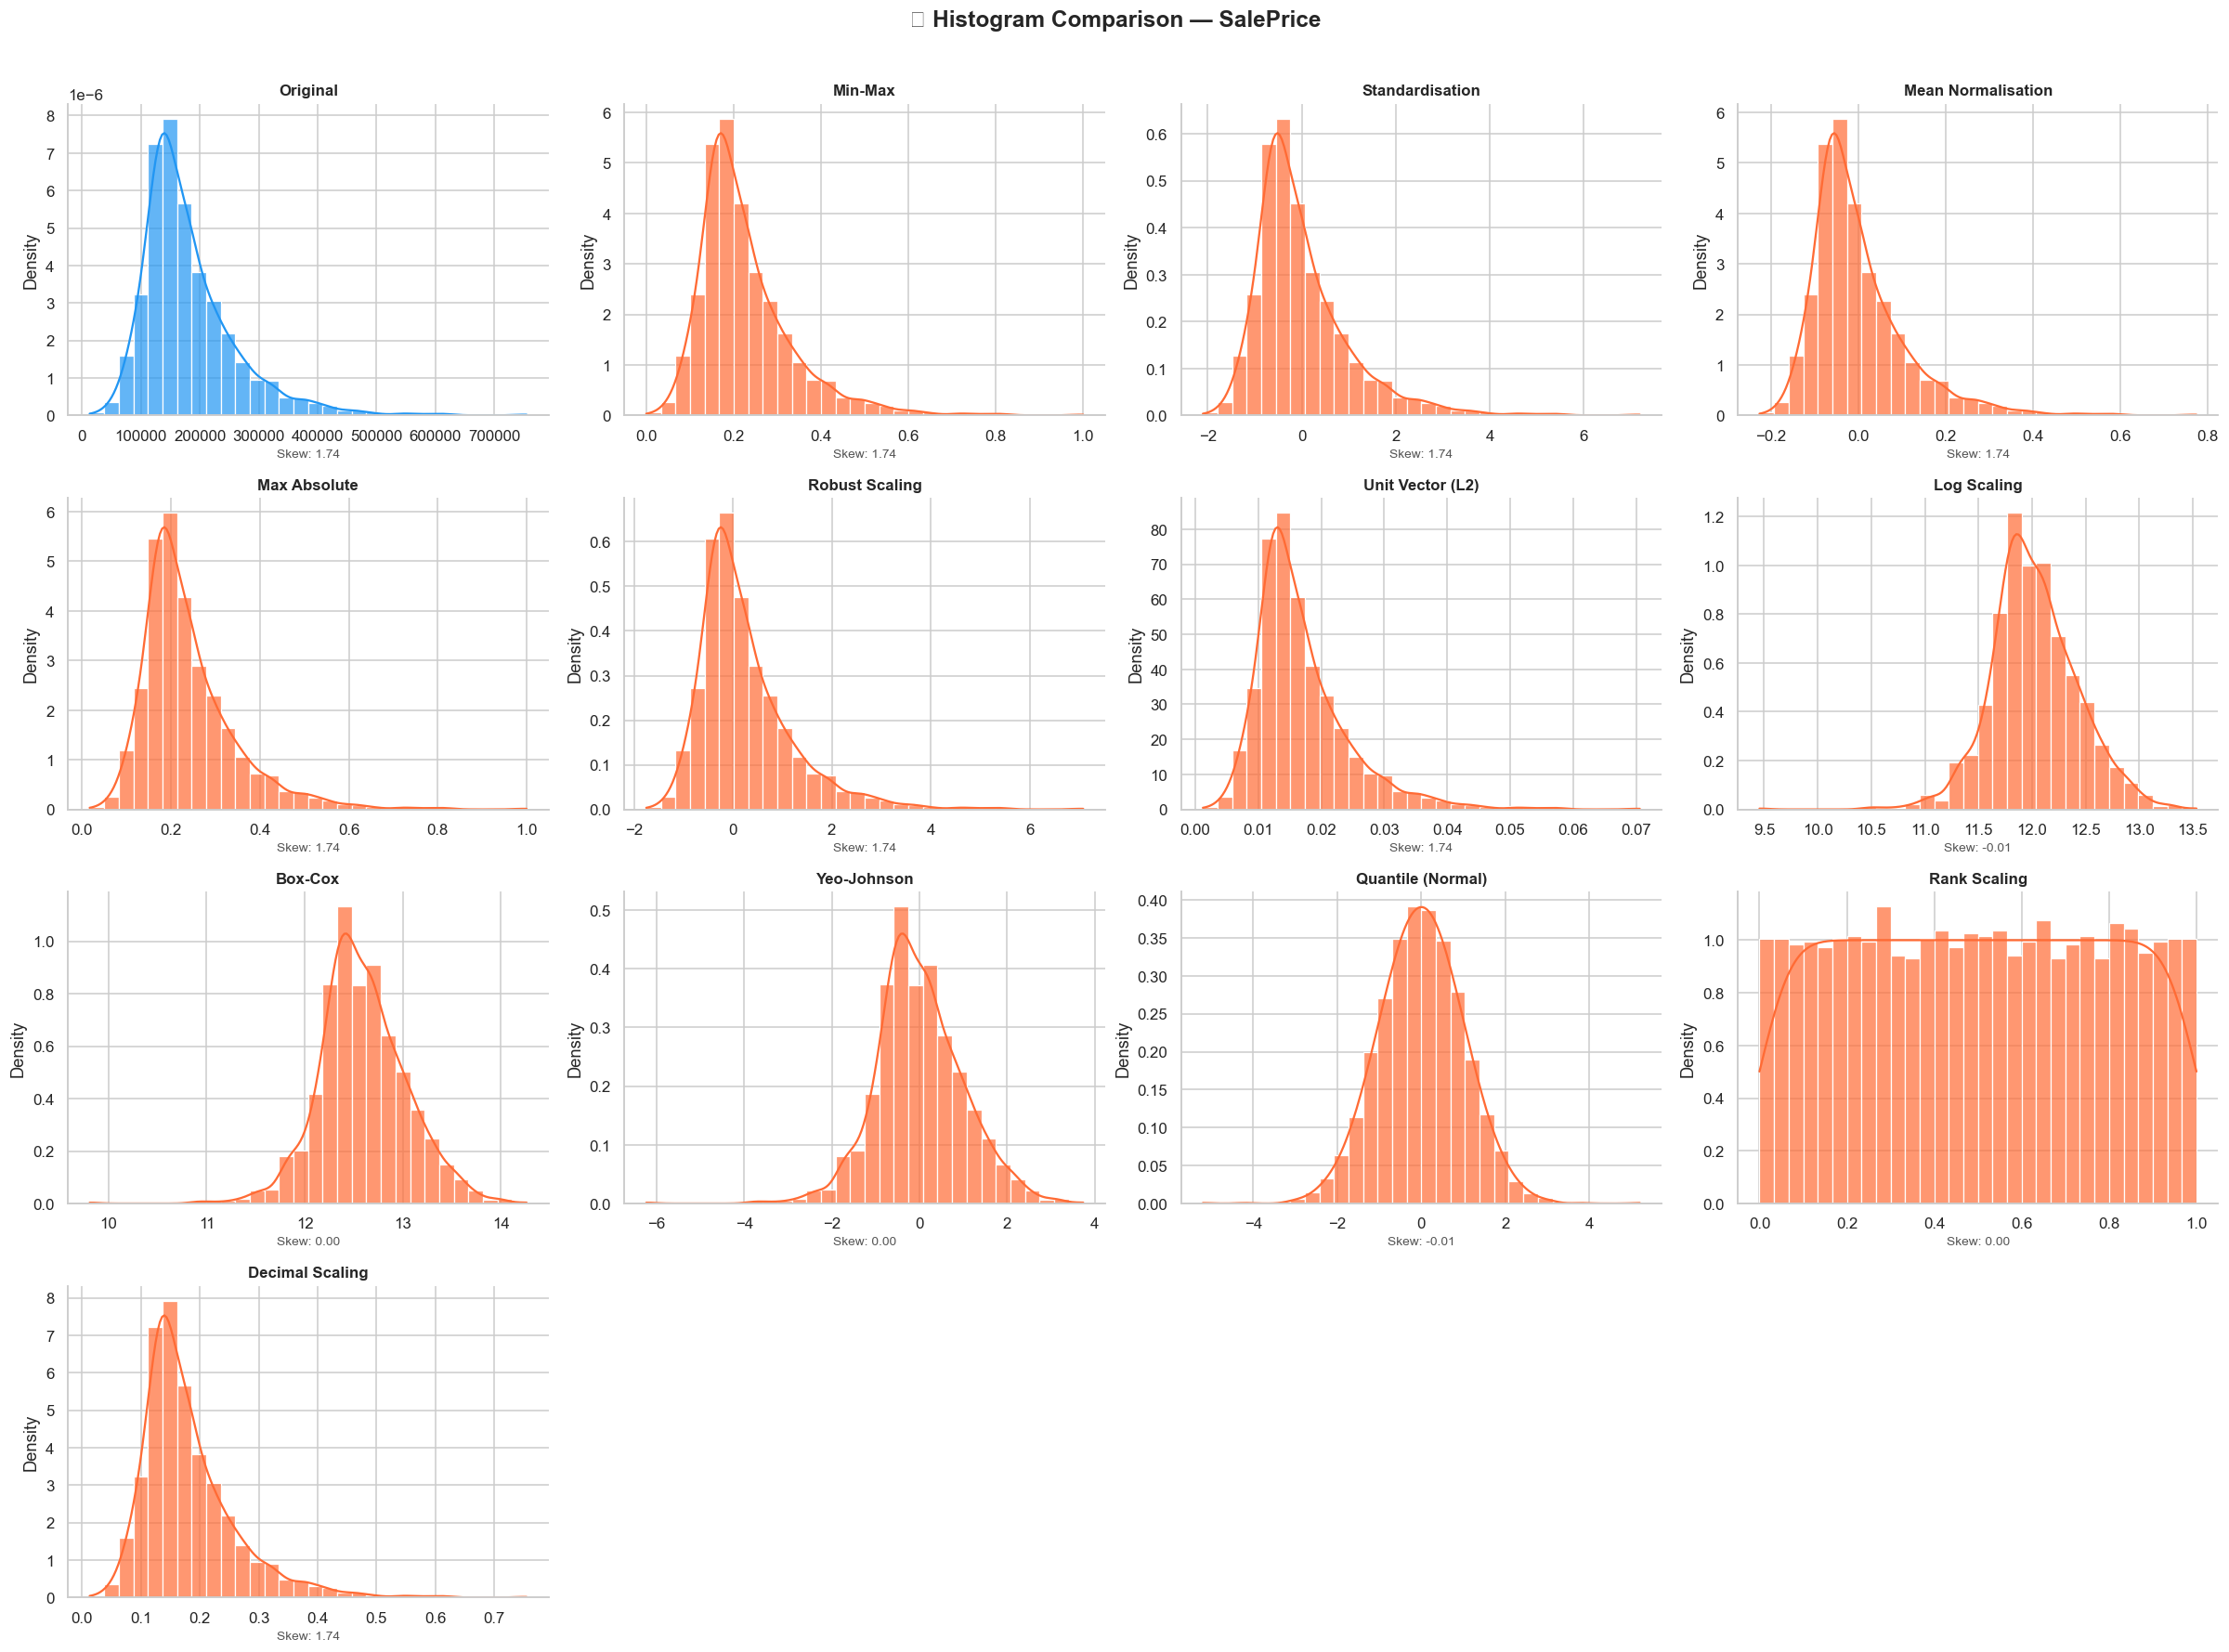

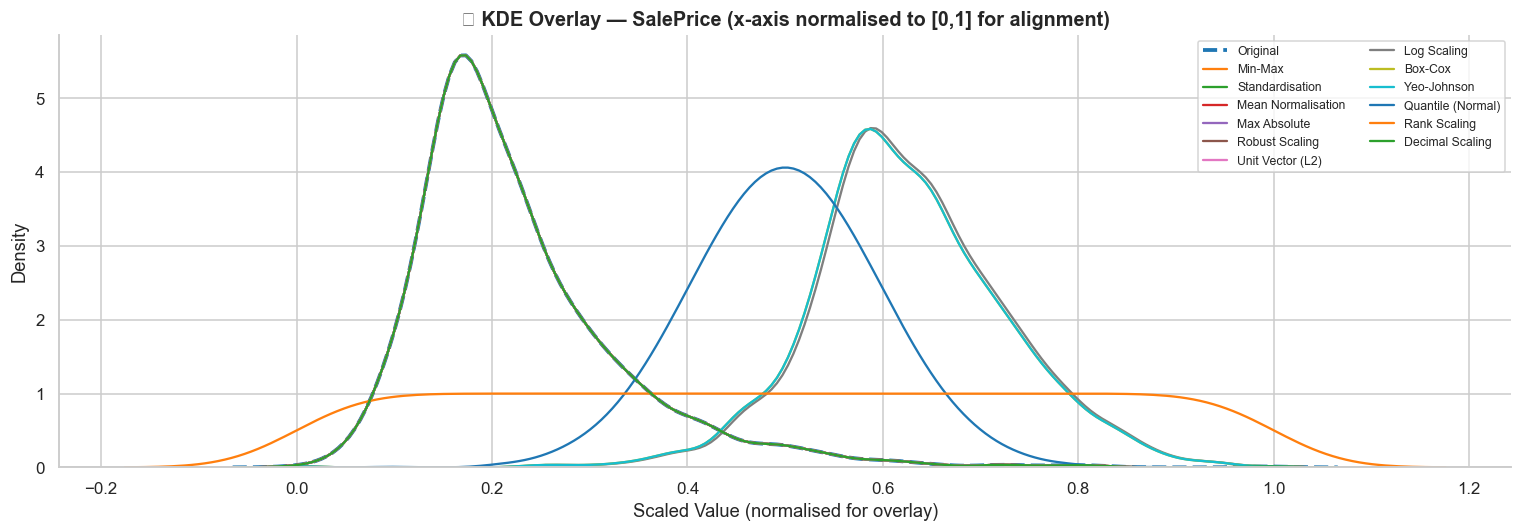

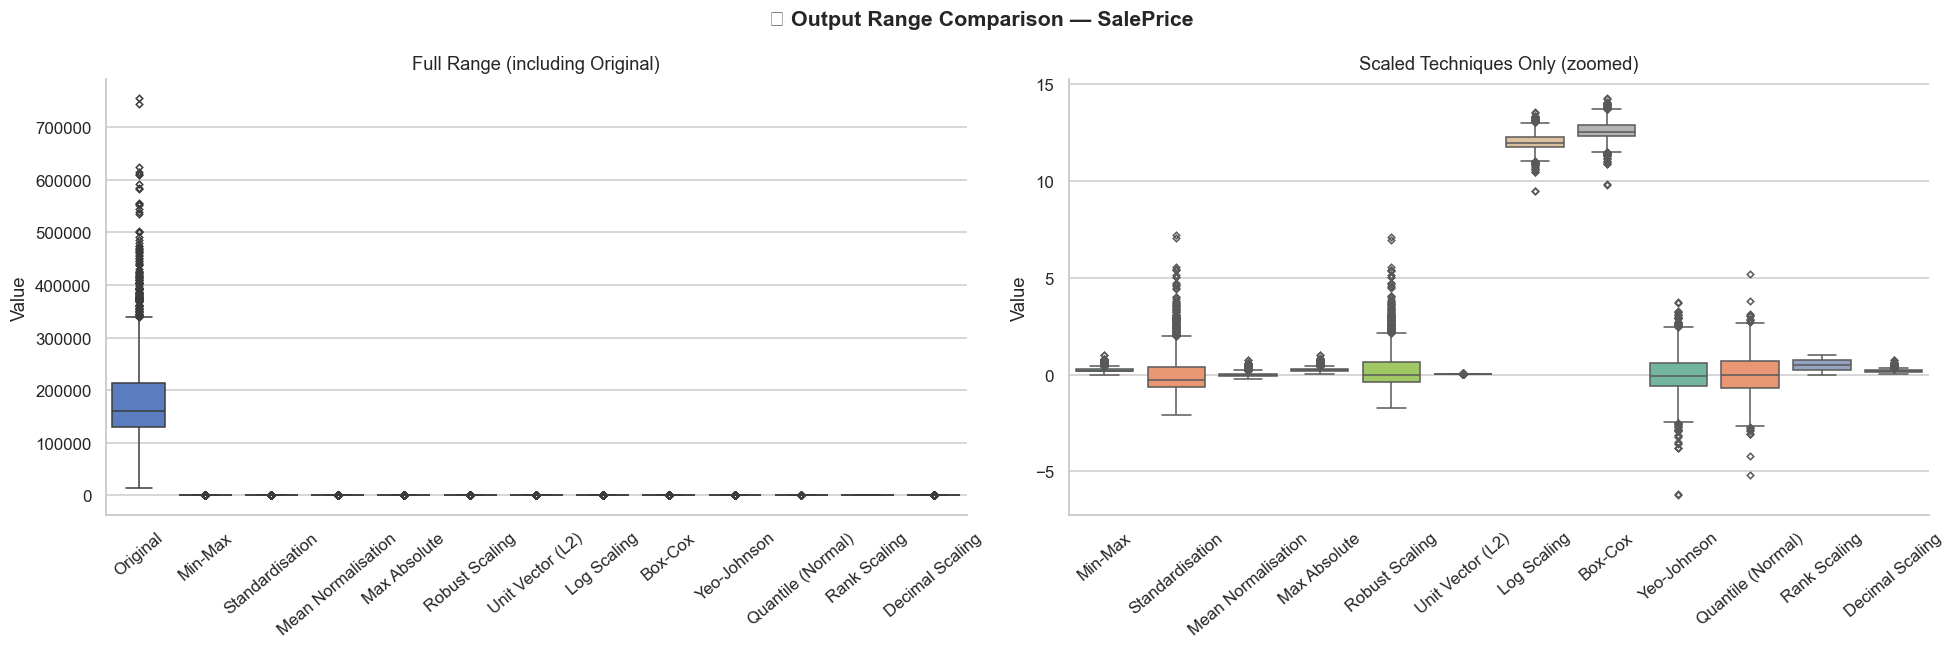

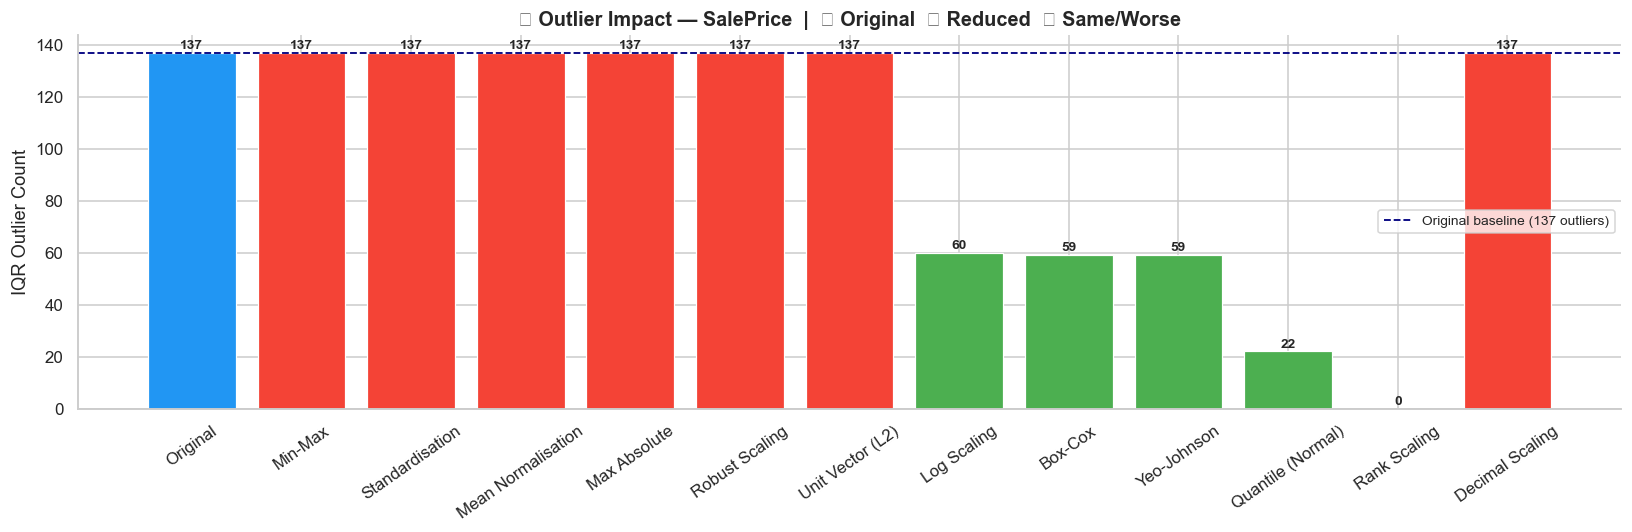

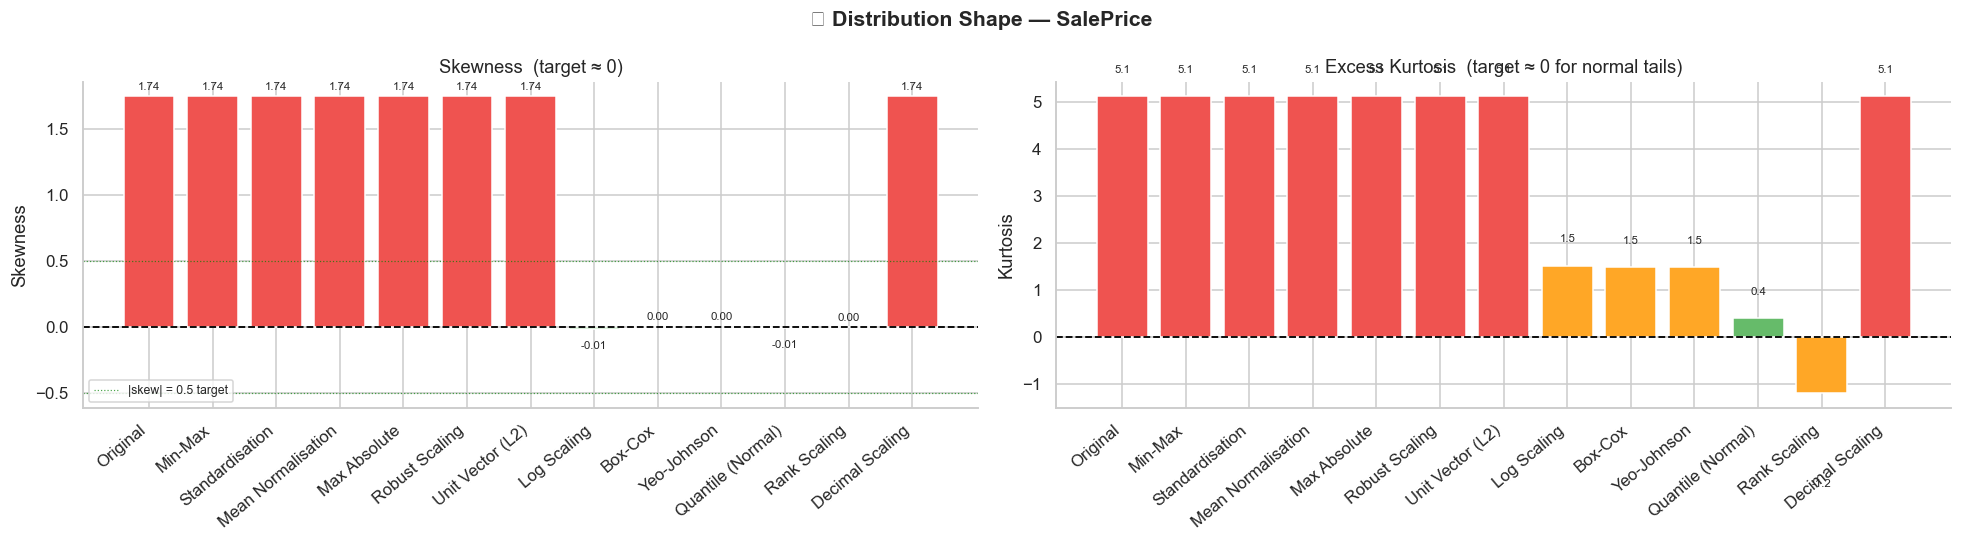

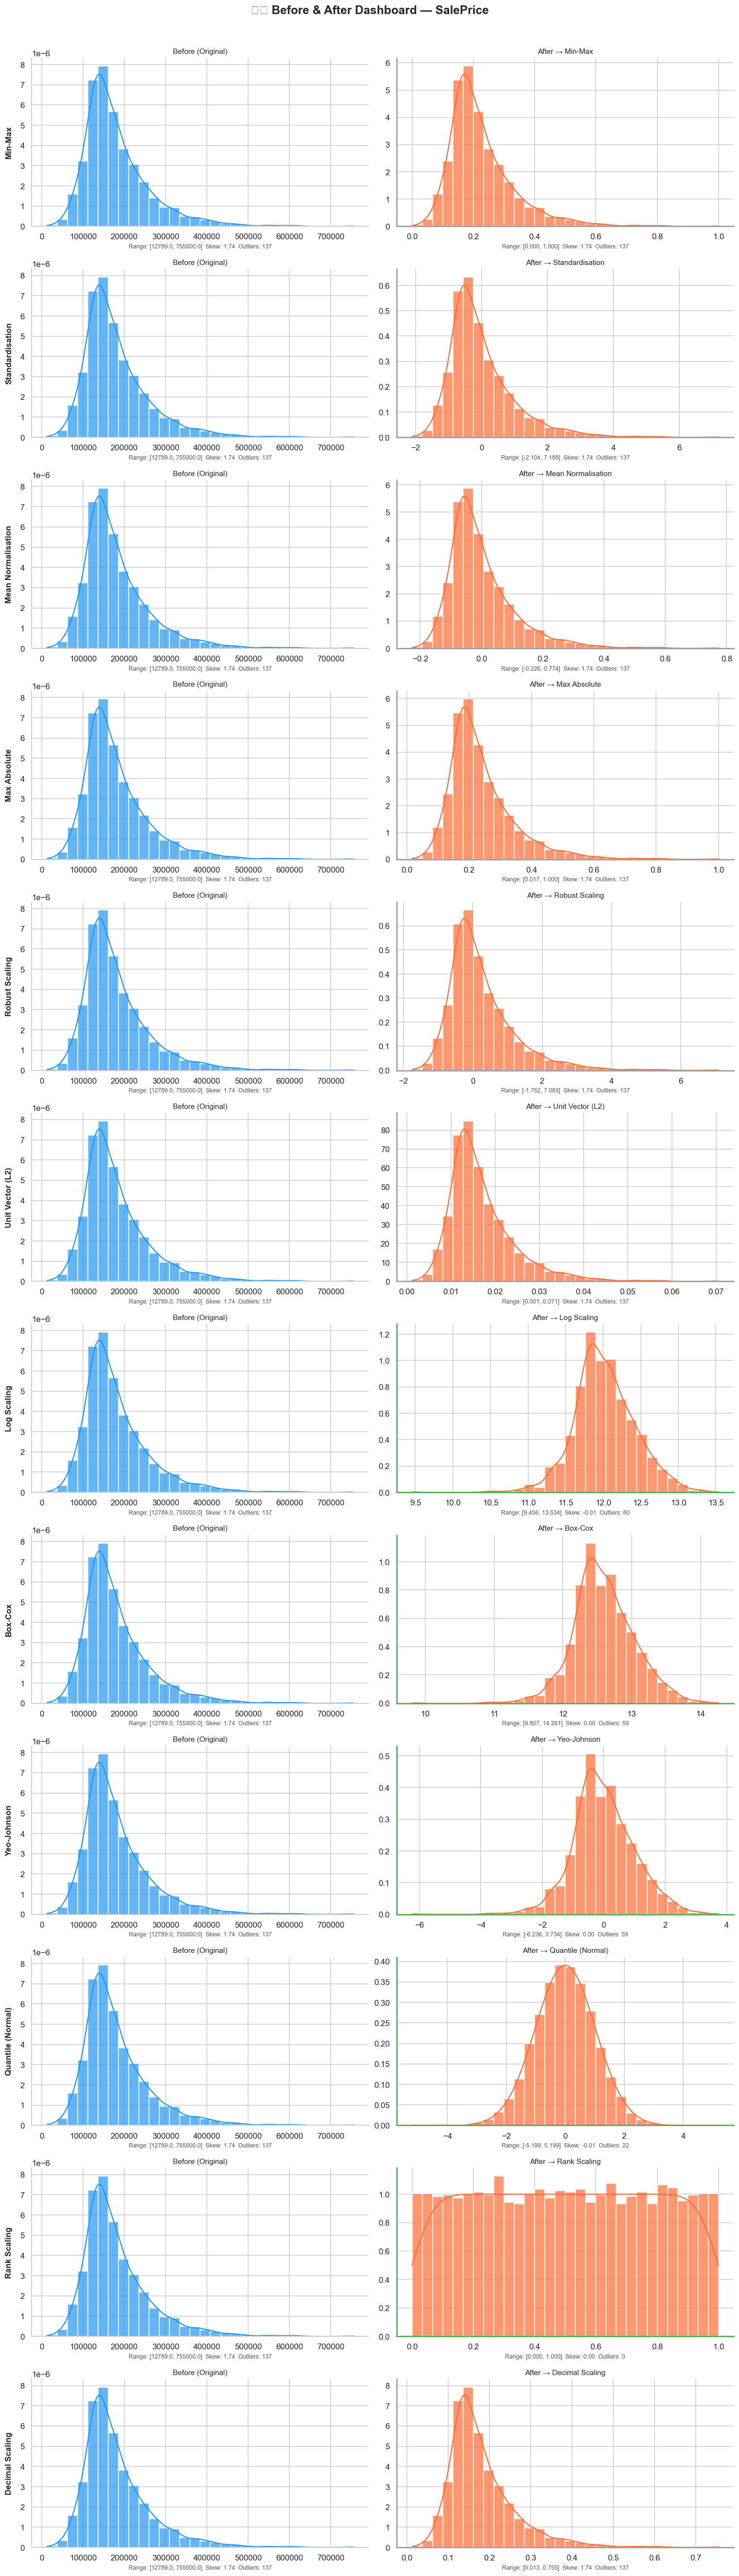

Legend: 🟢 green border = skewness improved vs original


In [12]:
# Run analysis for SalePrice
scaled_saleprice = run_full_analysis(data, 'SalePrice')


  Feature: Gr Liv Area


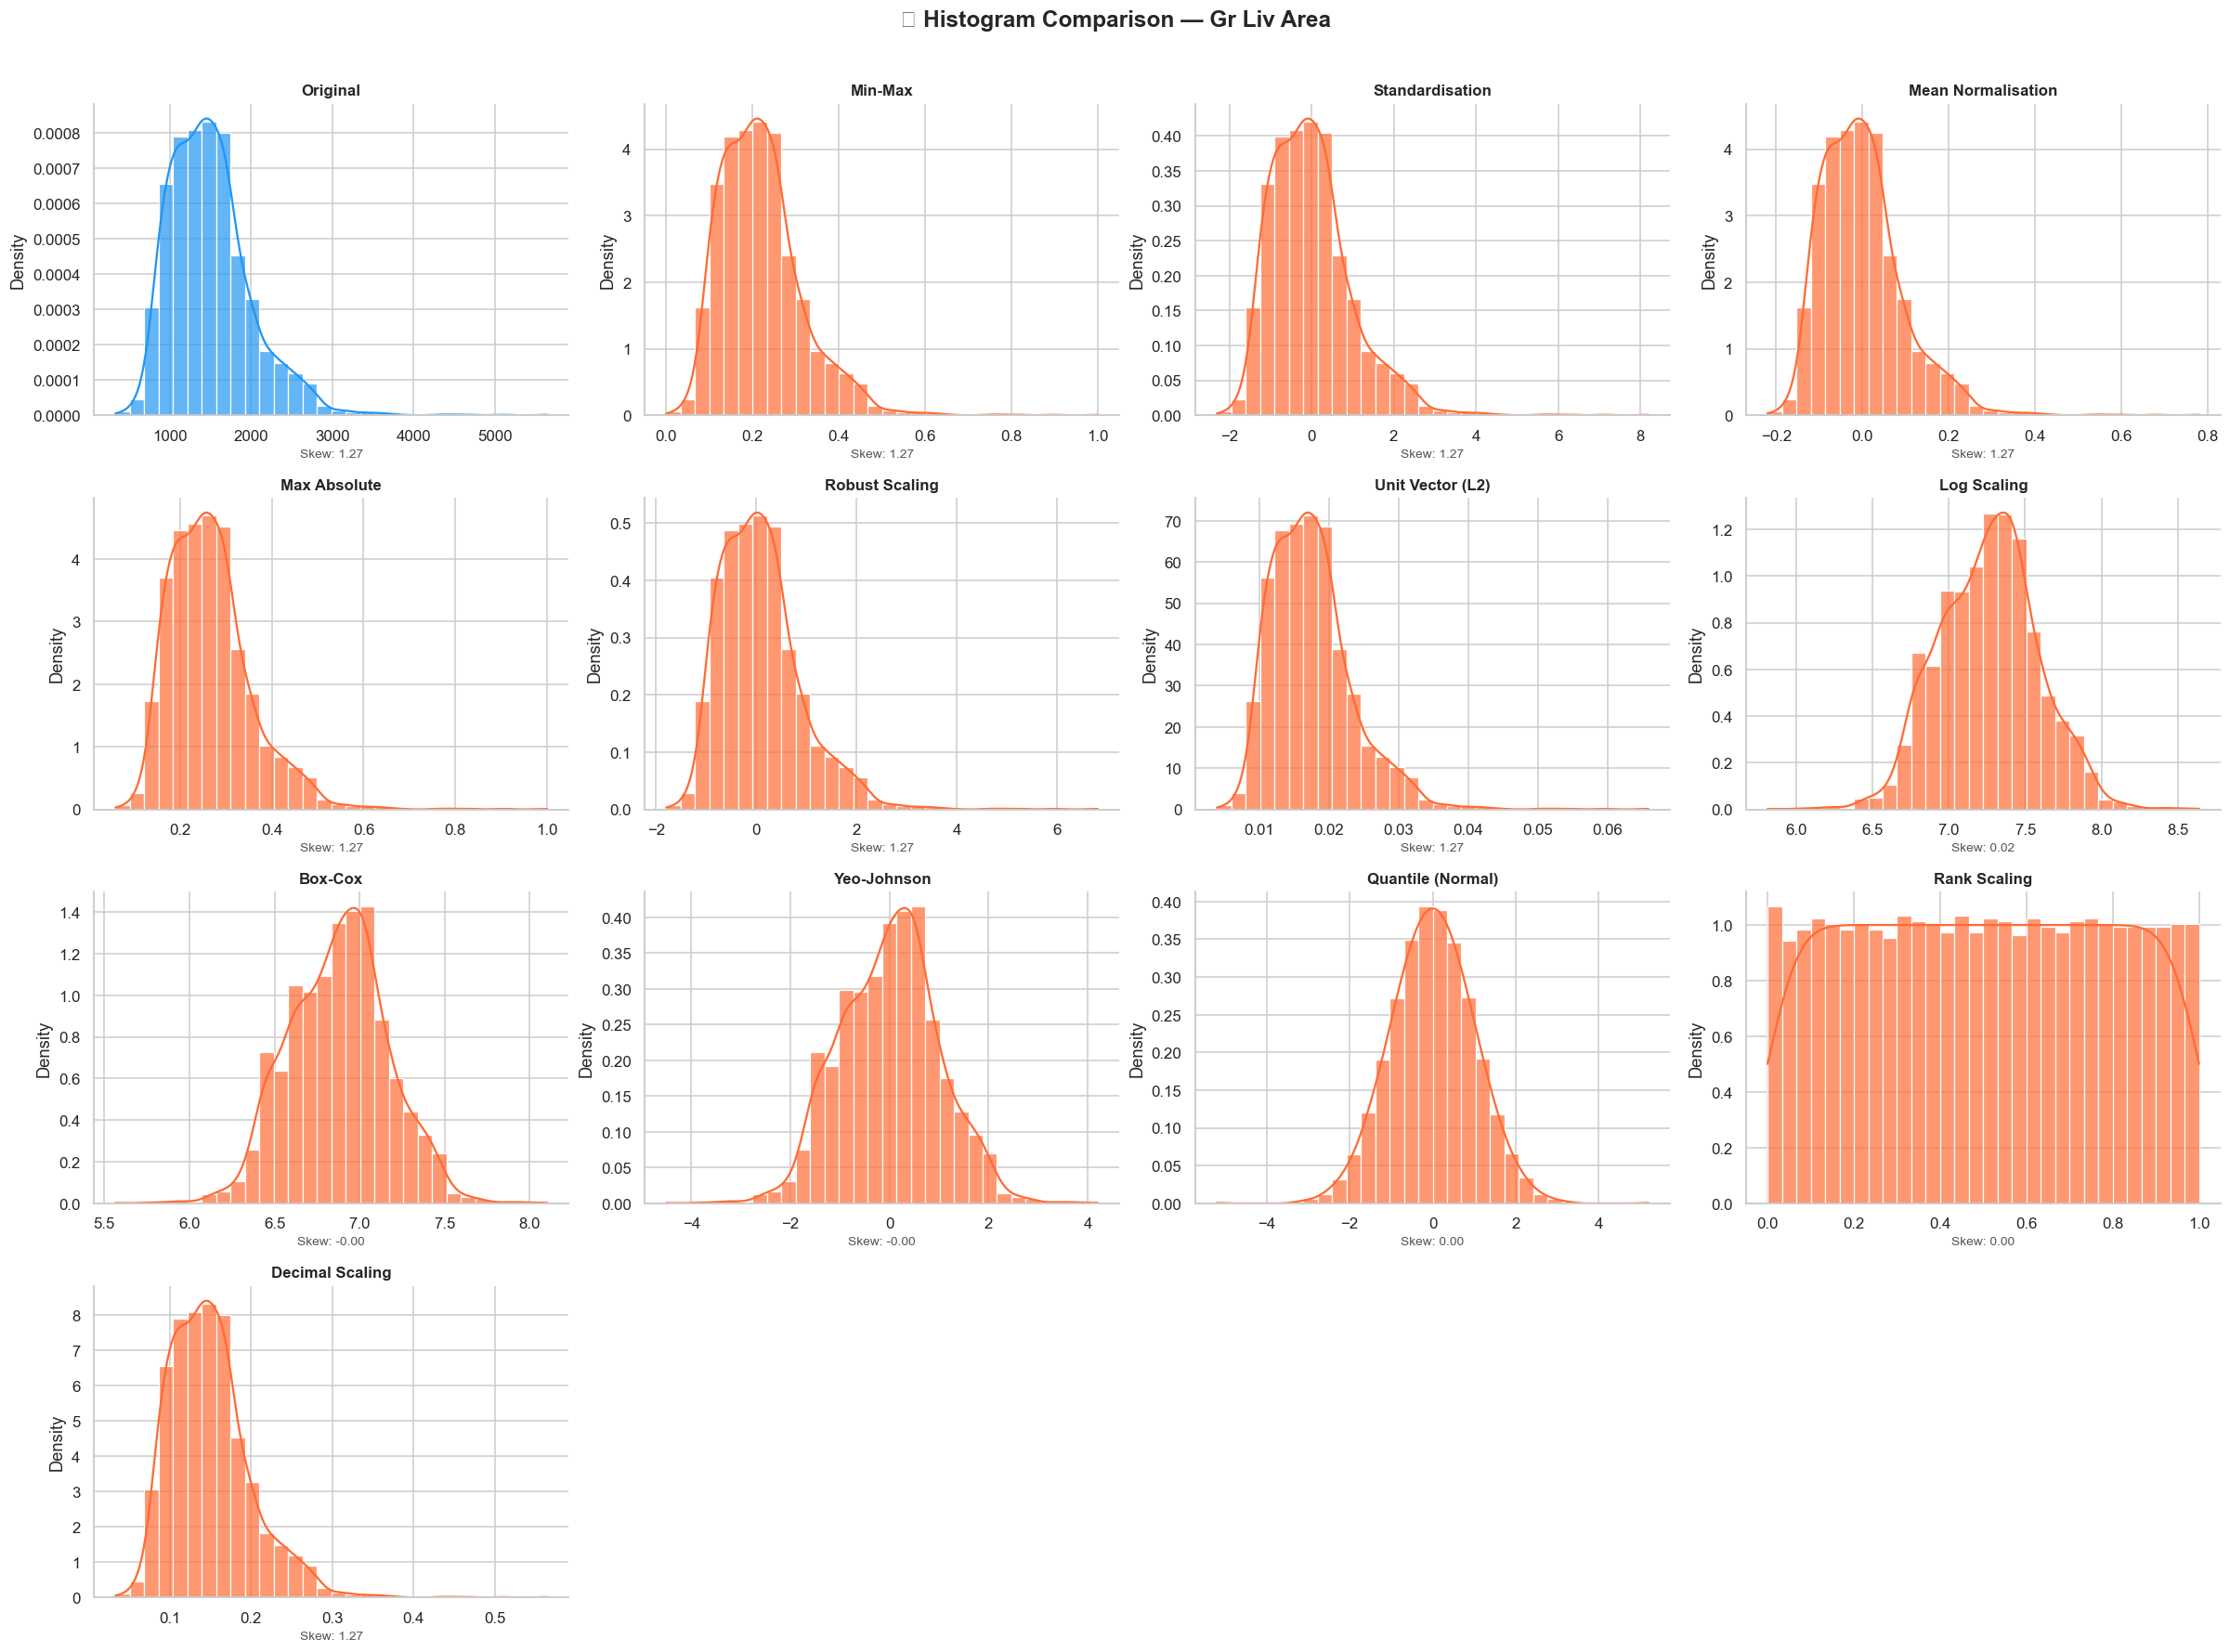

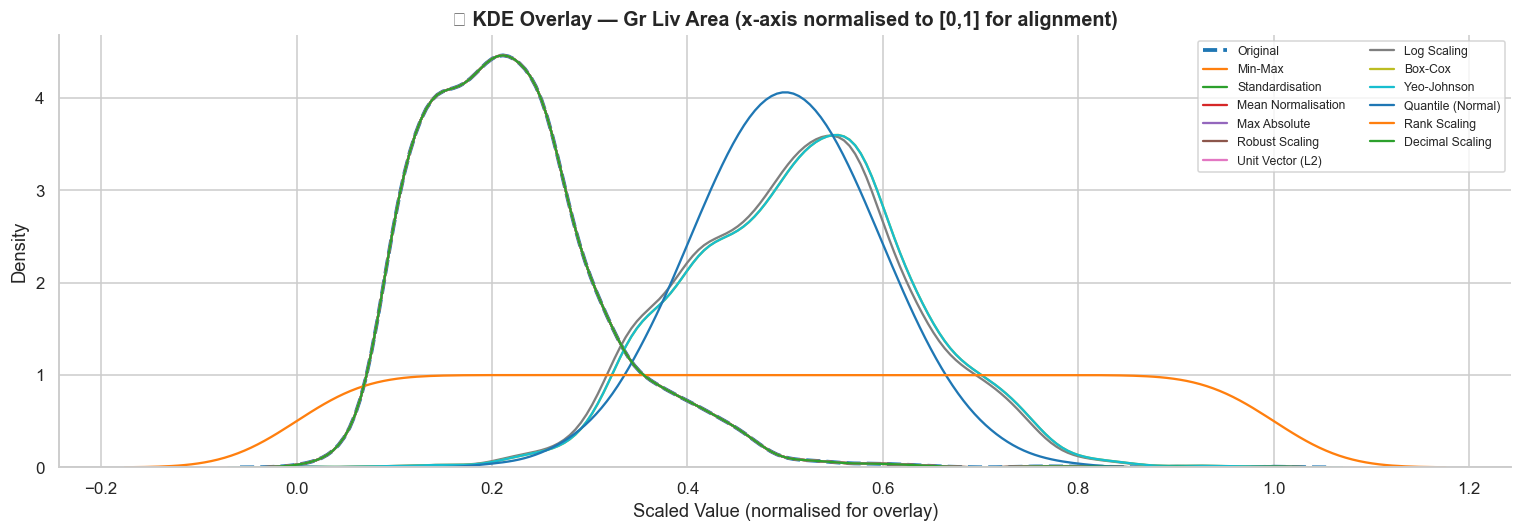

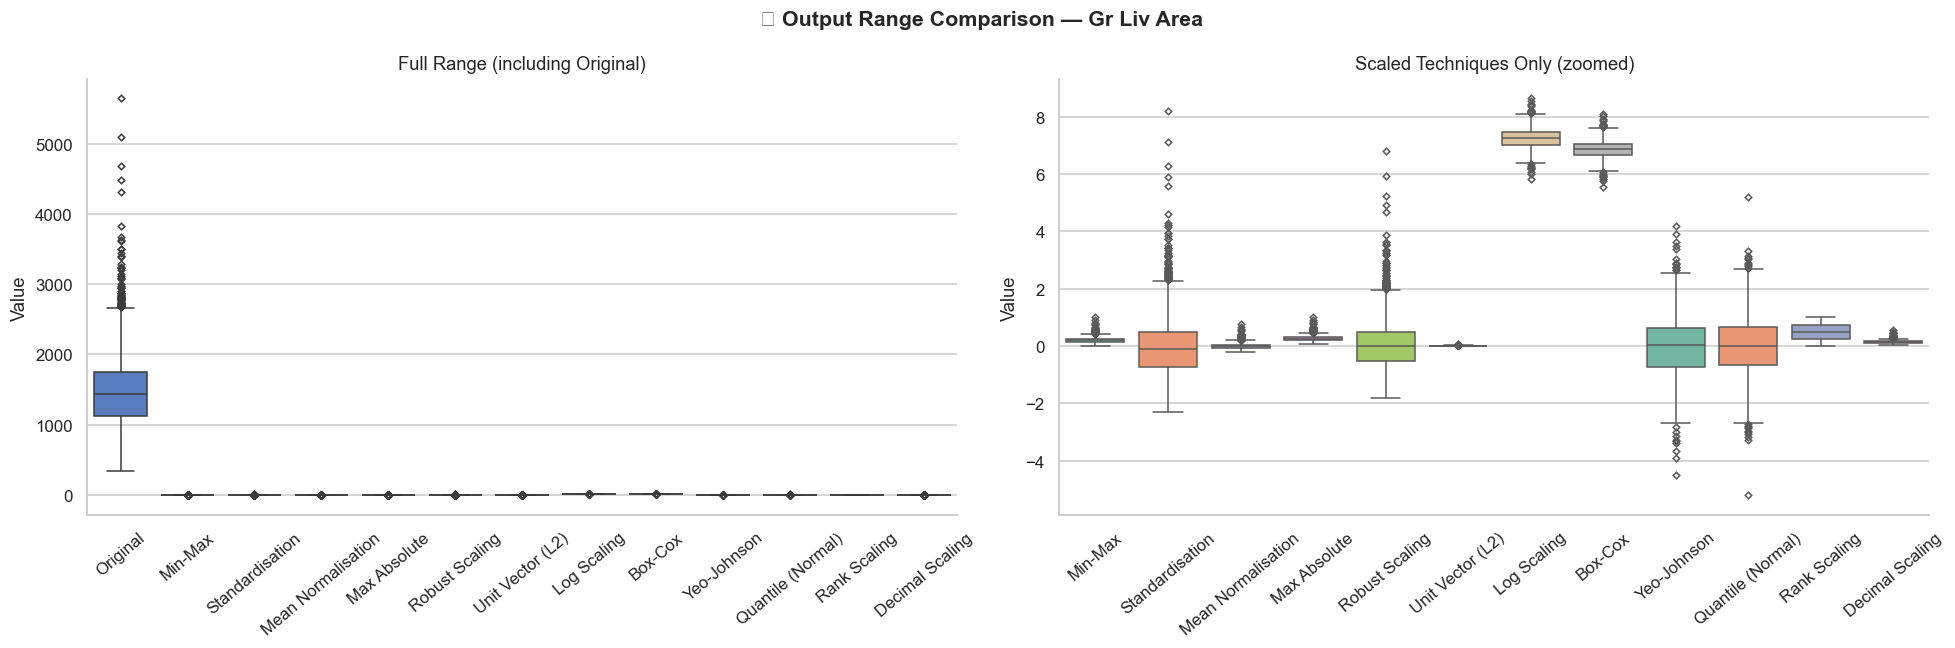

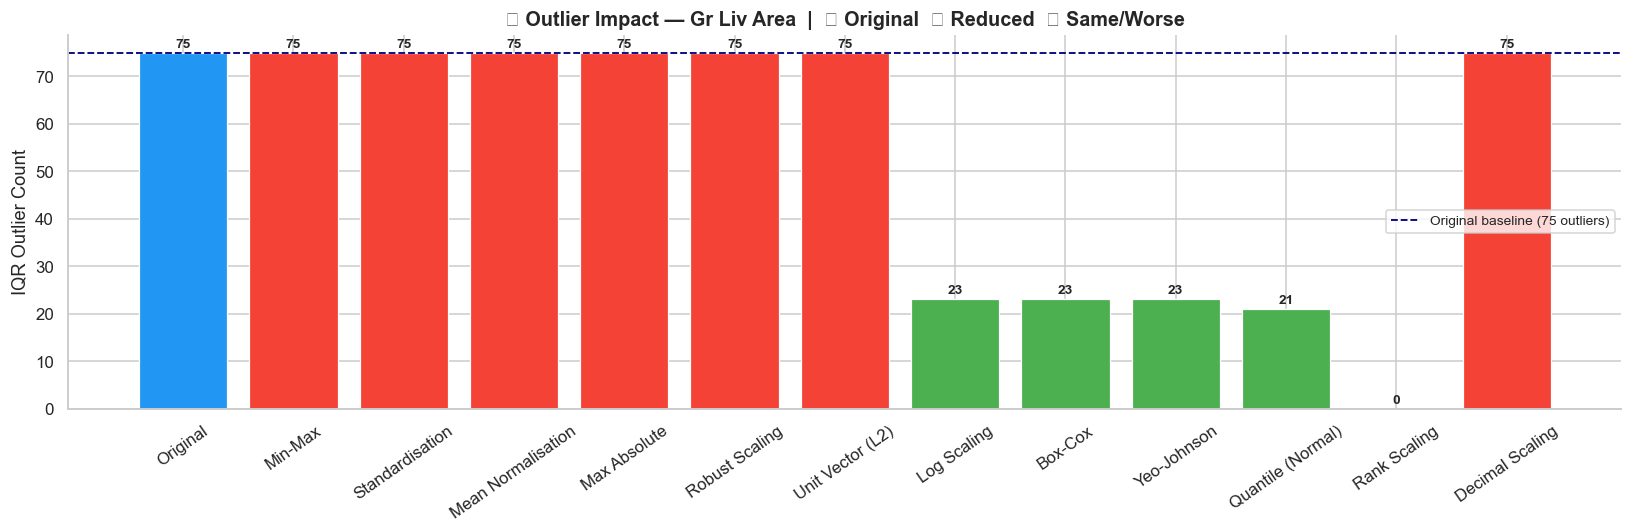

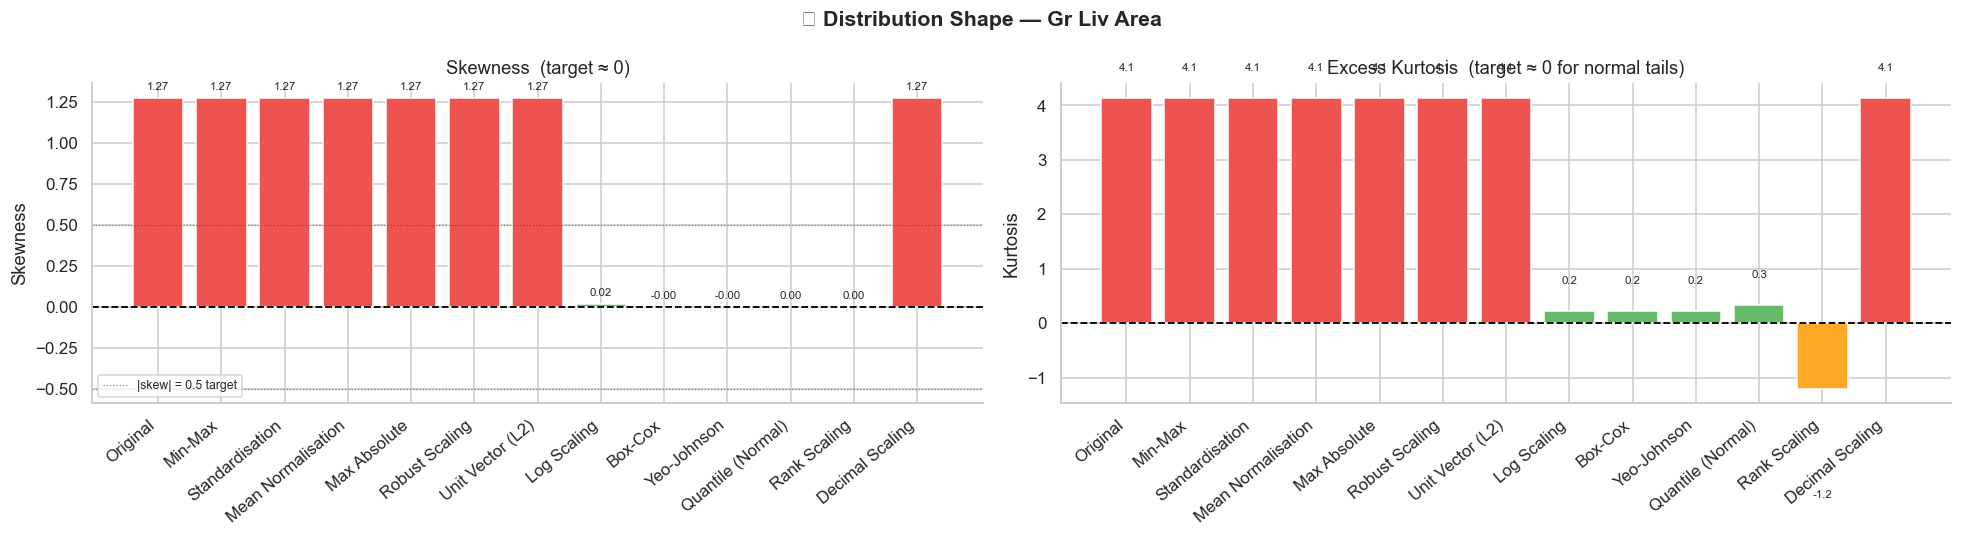

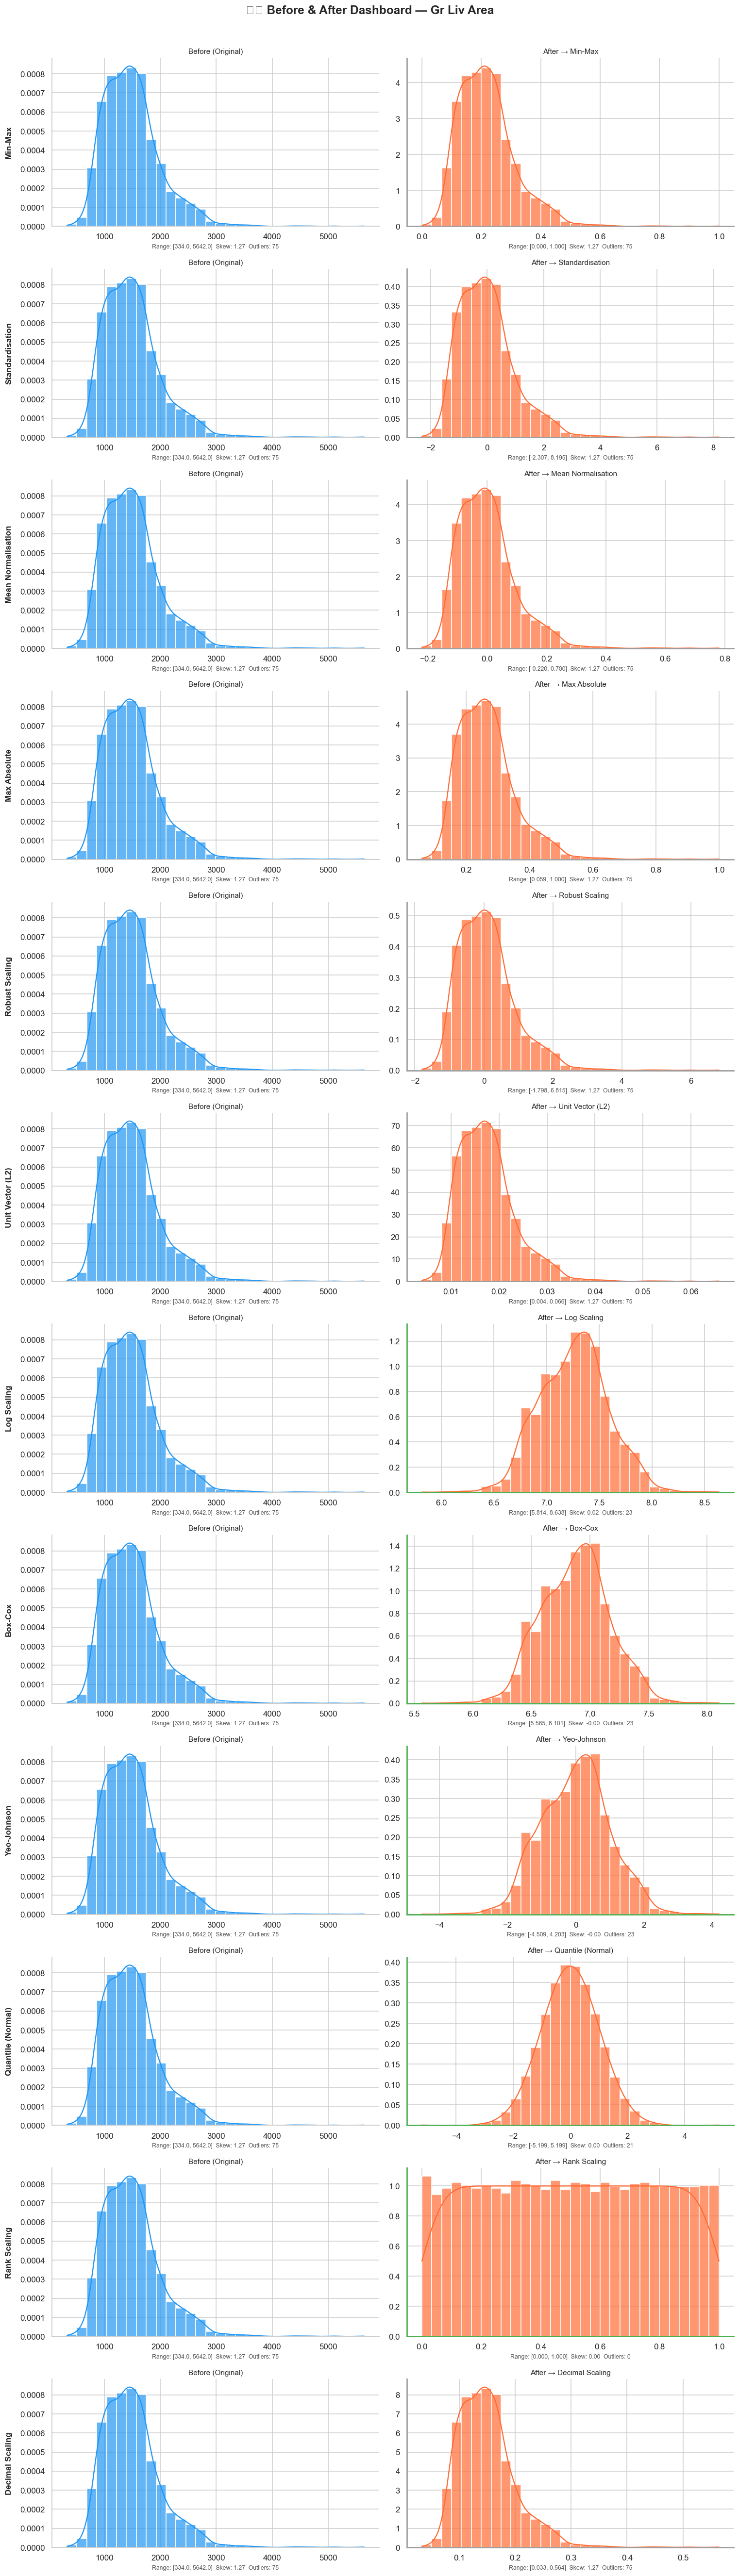

Legend: 🟢 green border = skewness improved vs original


In [13]:
# Run analysis for Gr Liv Area
scaled_grliv = run_full_analysis(data, 'Gr Liv Area')


  Feature: Lot Area


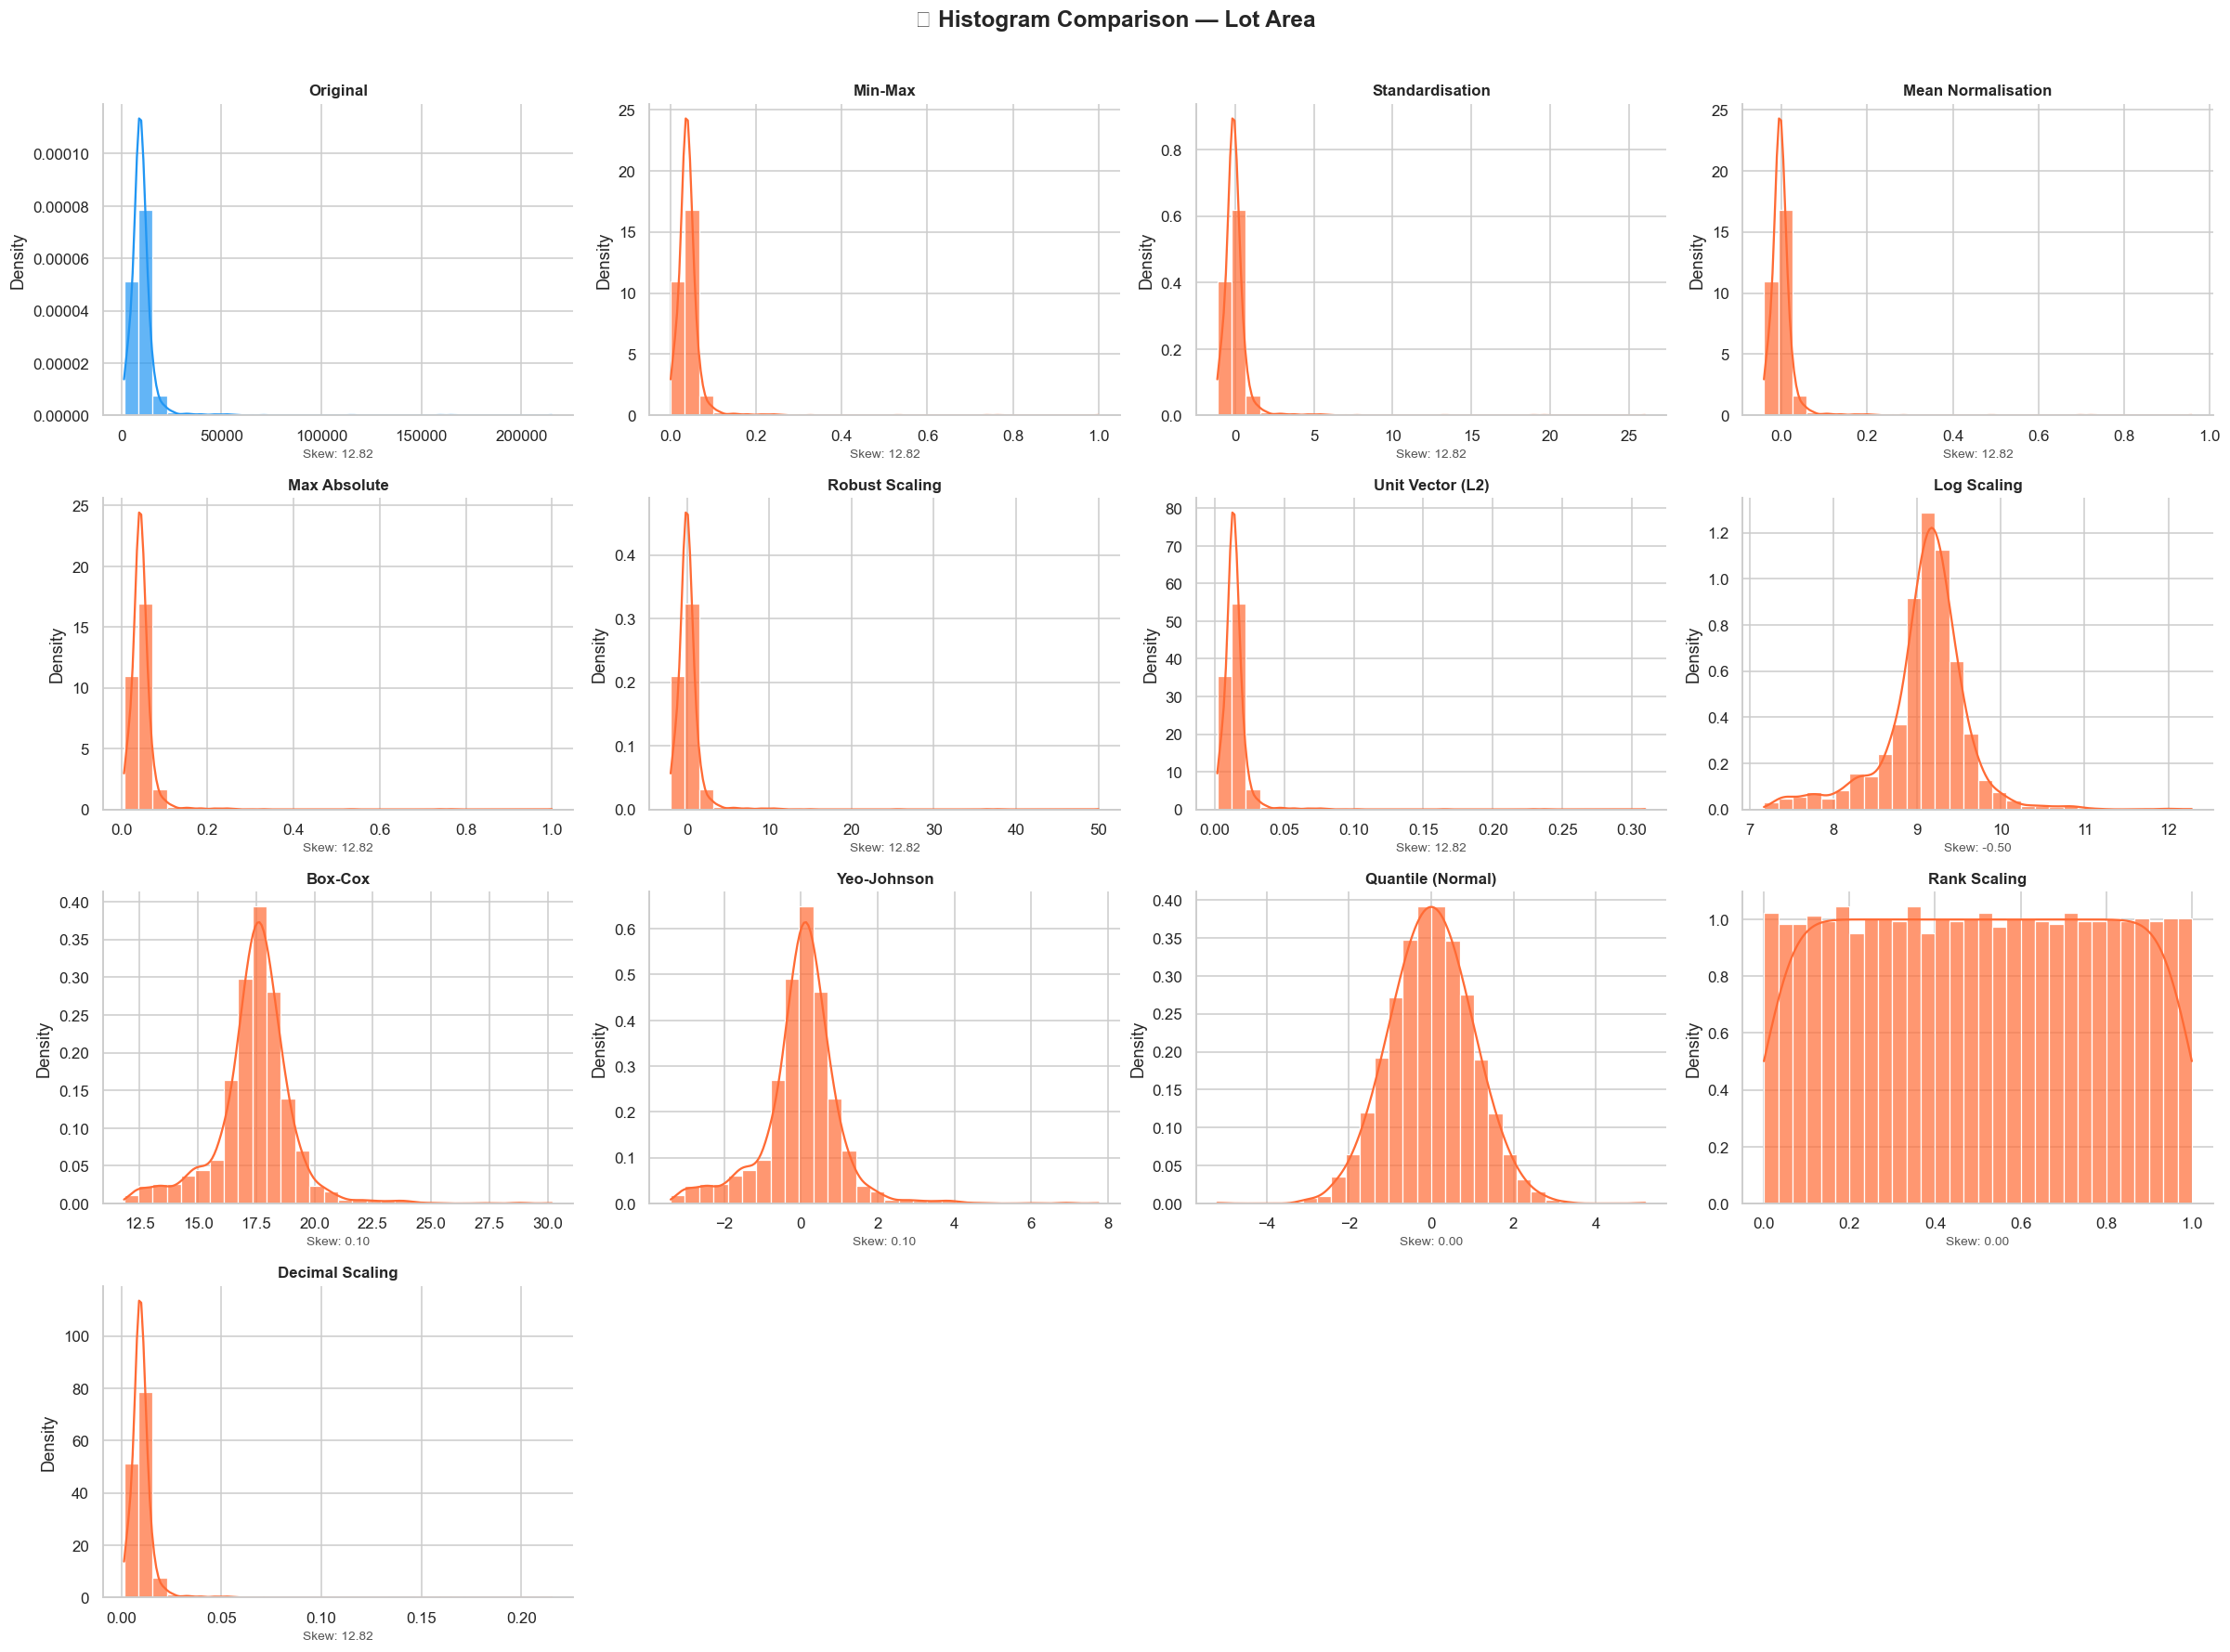

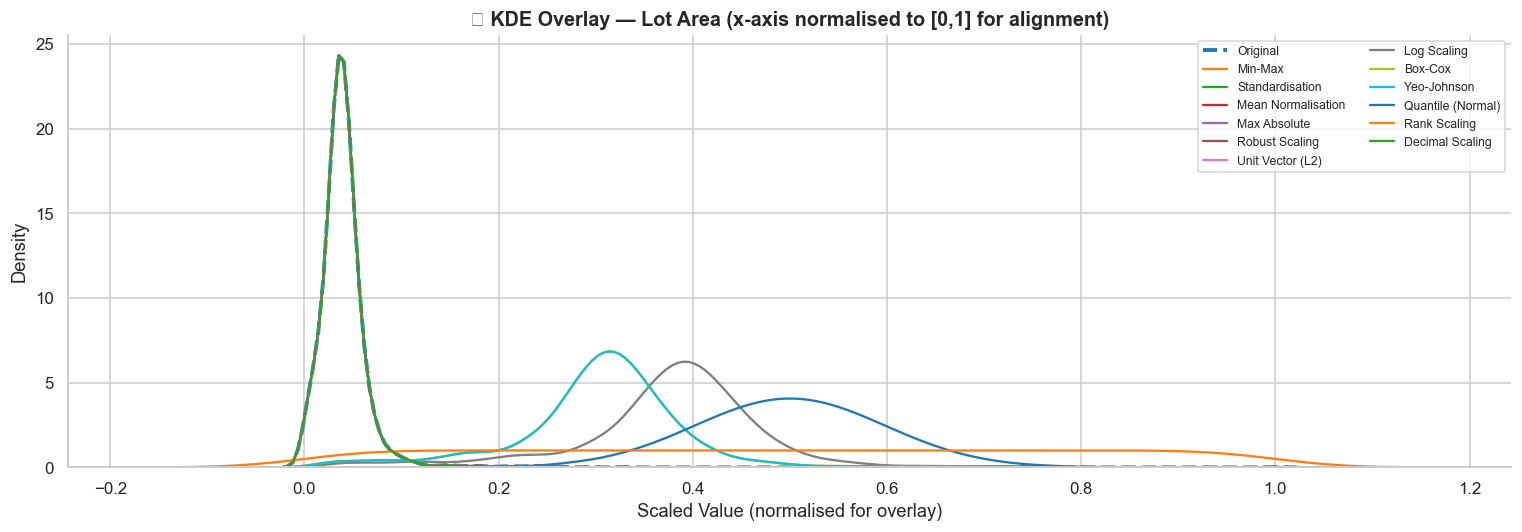

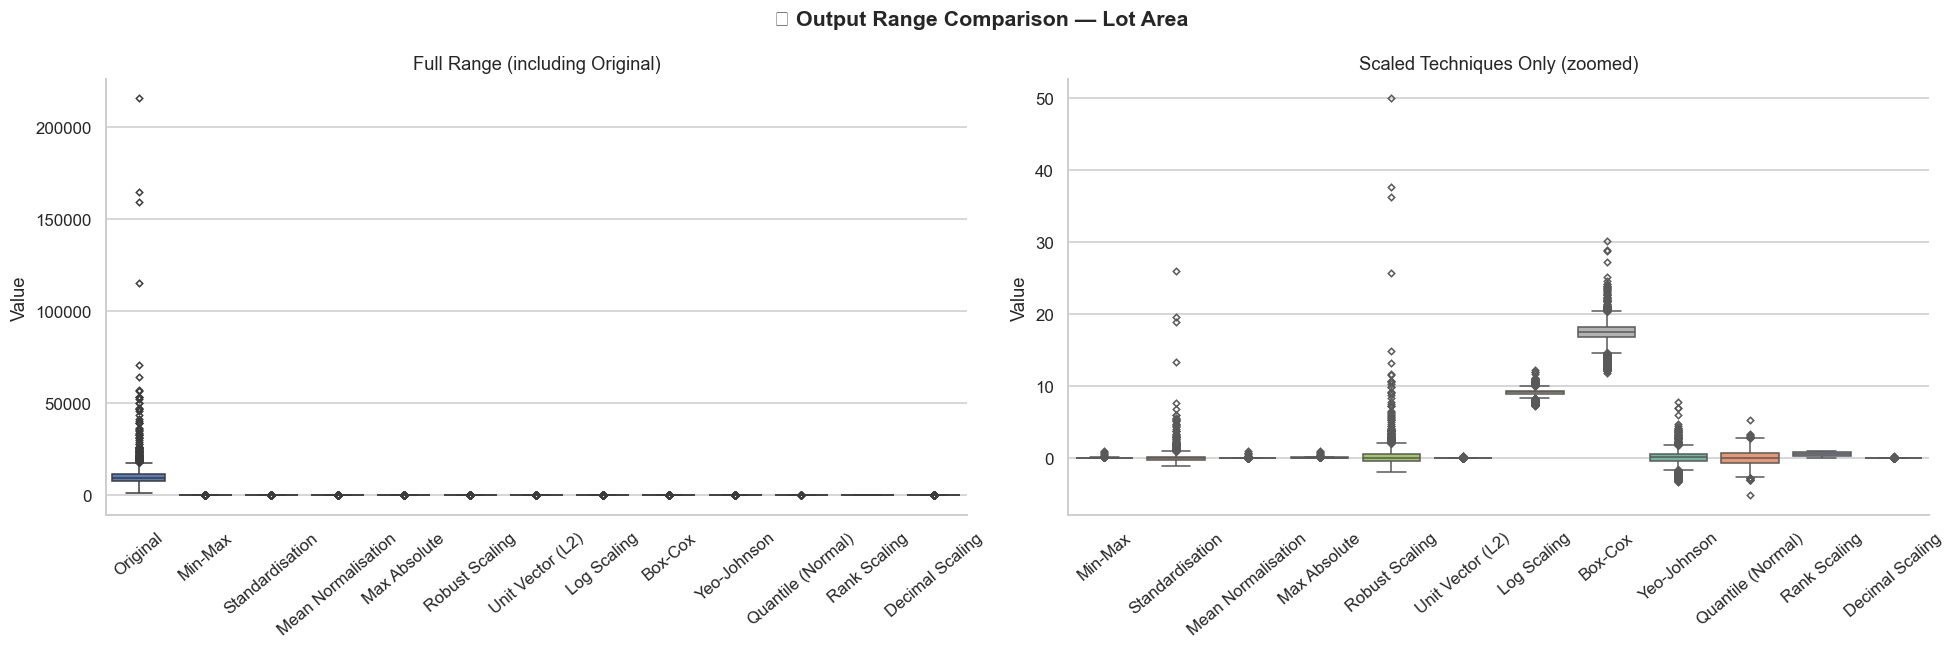

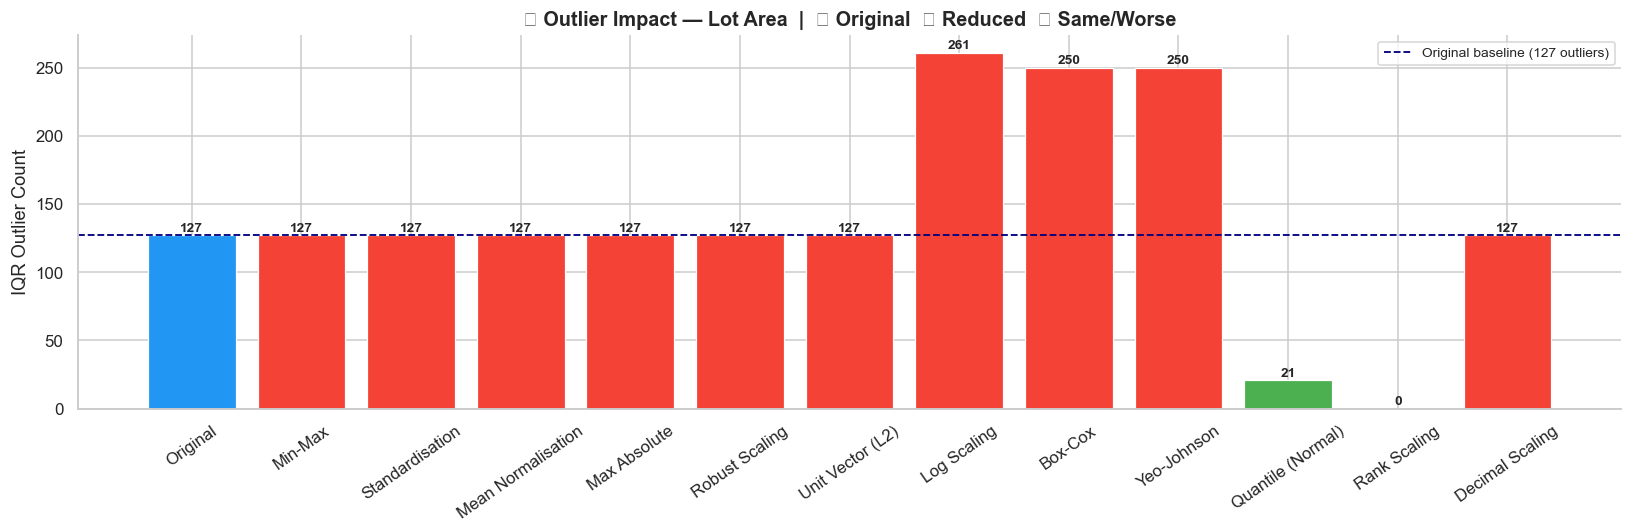

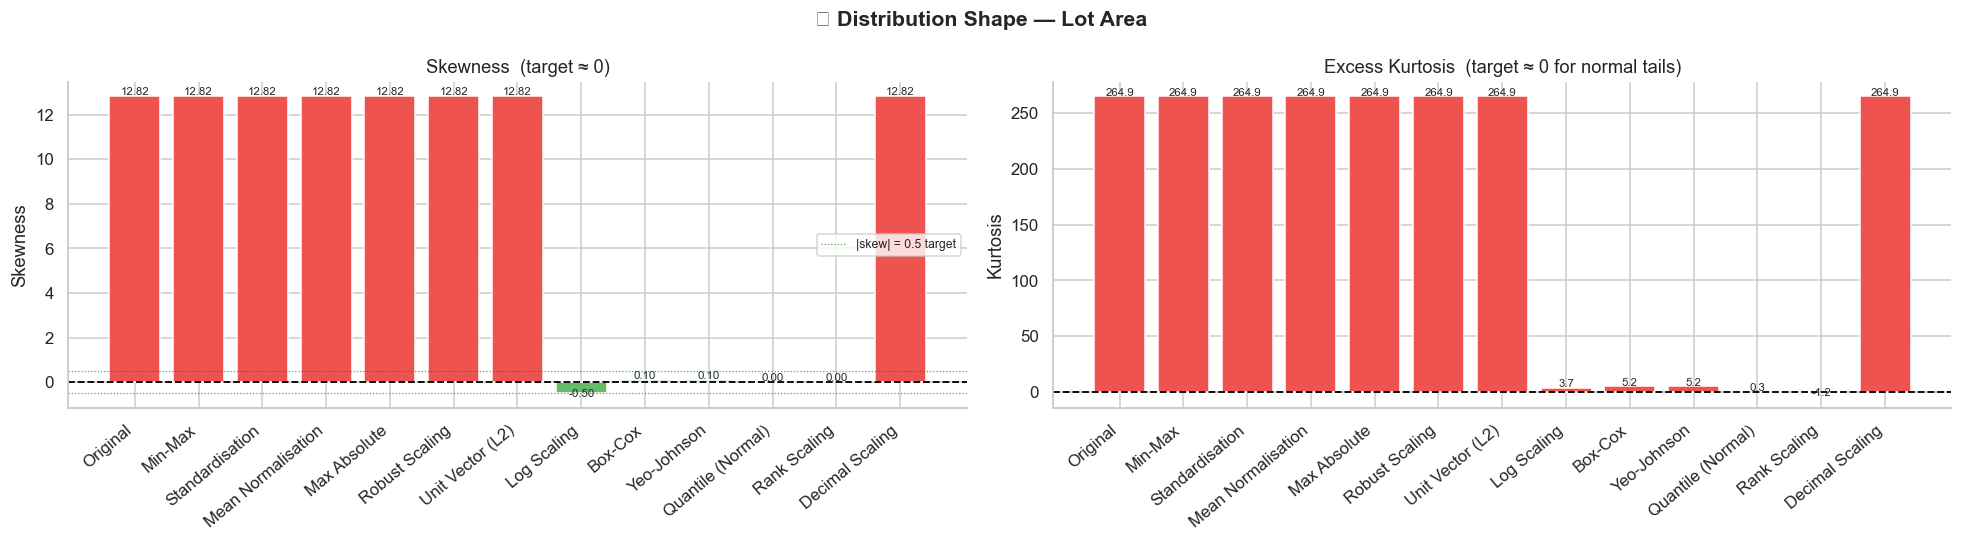

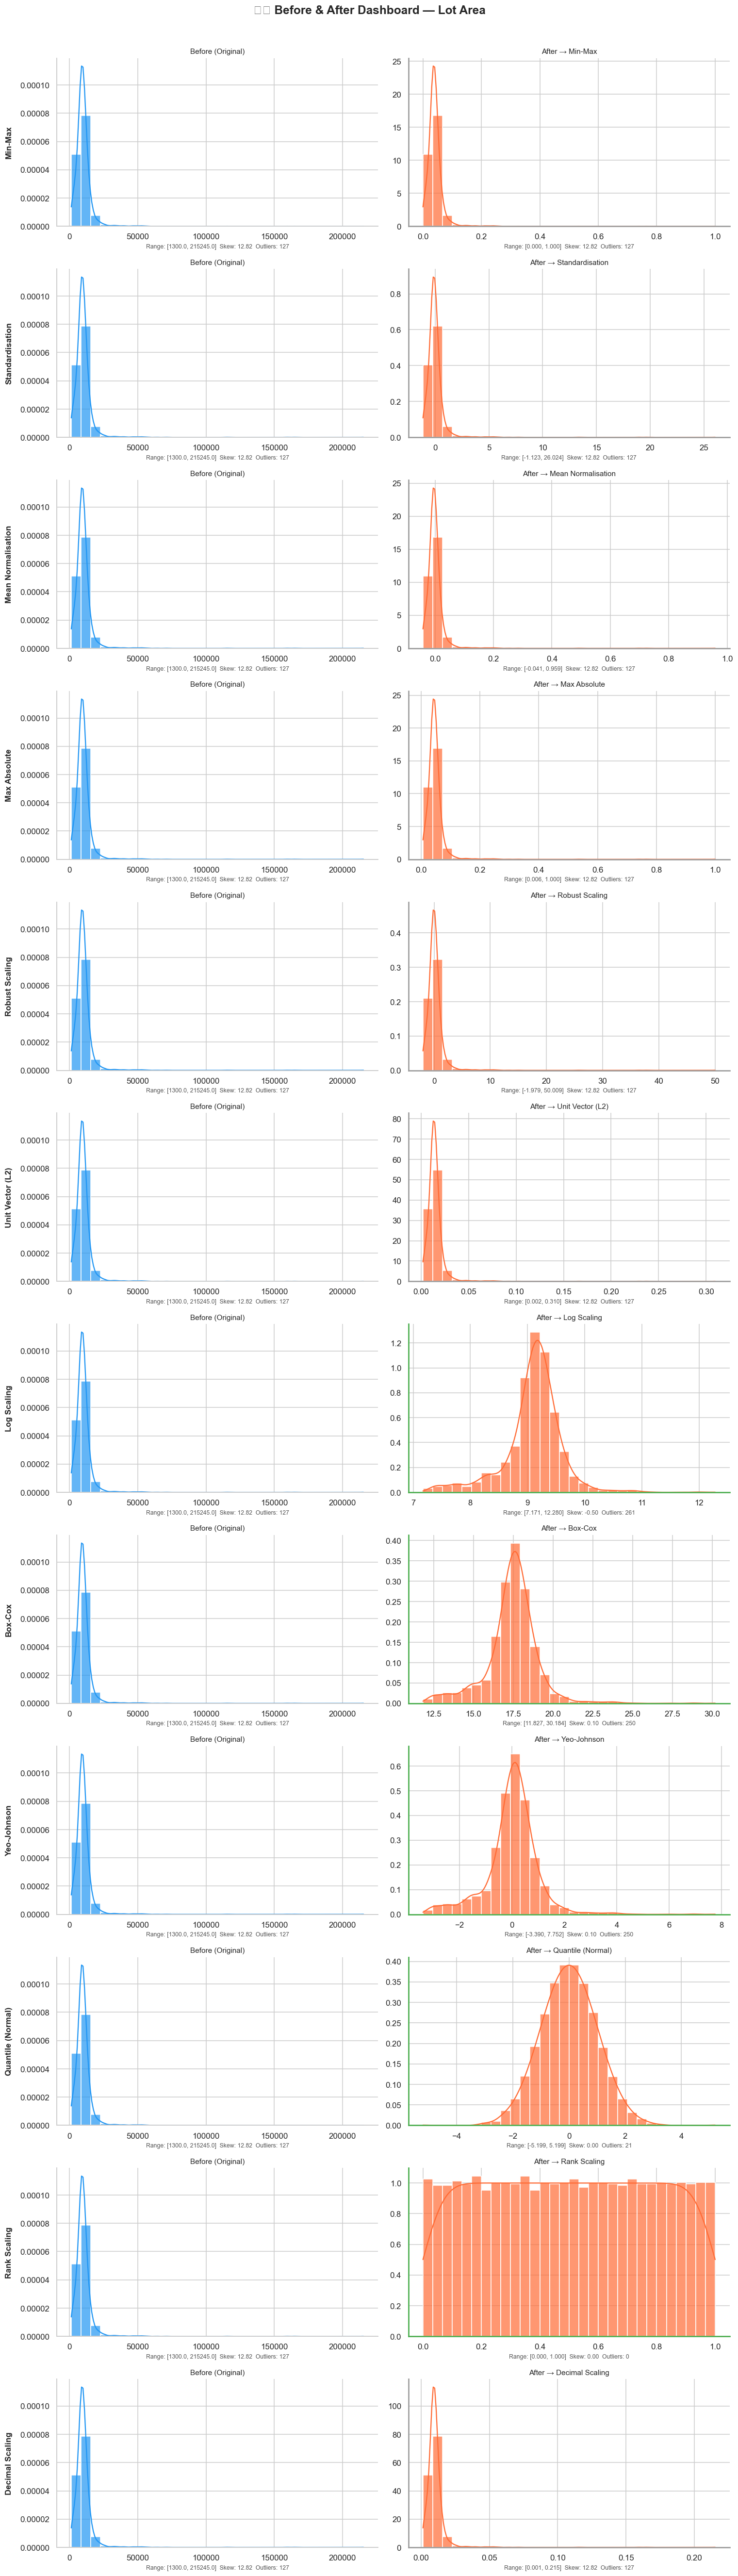

Legend: 🟢 green border = skewness improved vs original


In [14]:
# Run analysis for Lot Area
scaled_lot = run_full_analysis(data, 'Lot Area')


  Feature: Total Bsmt SF


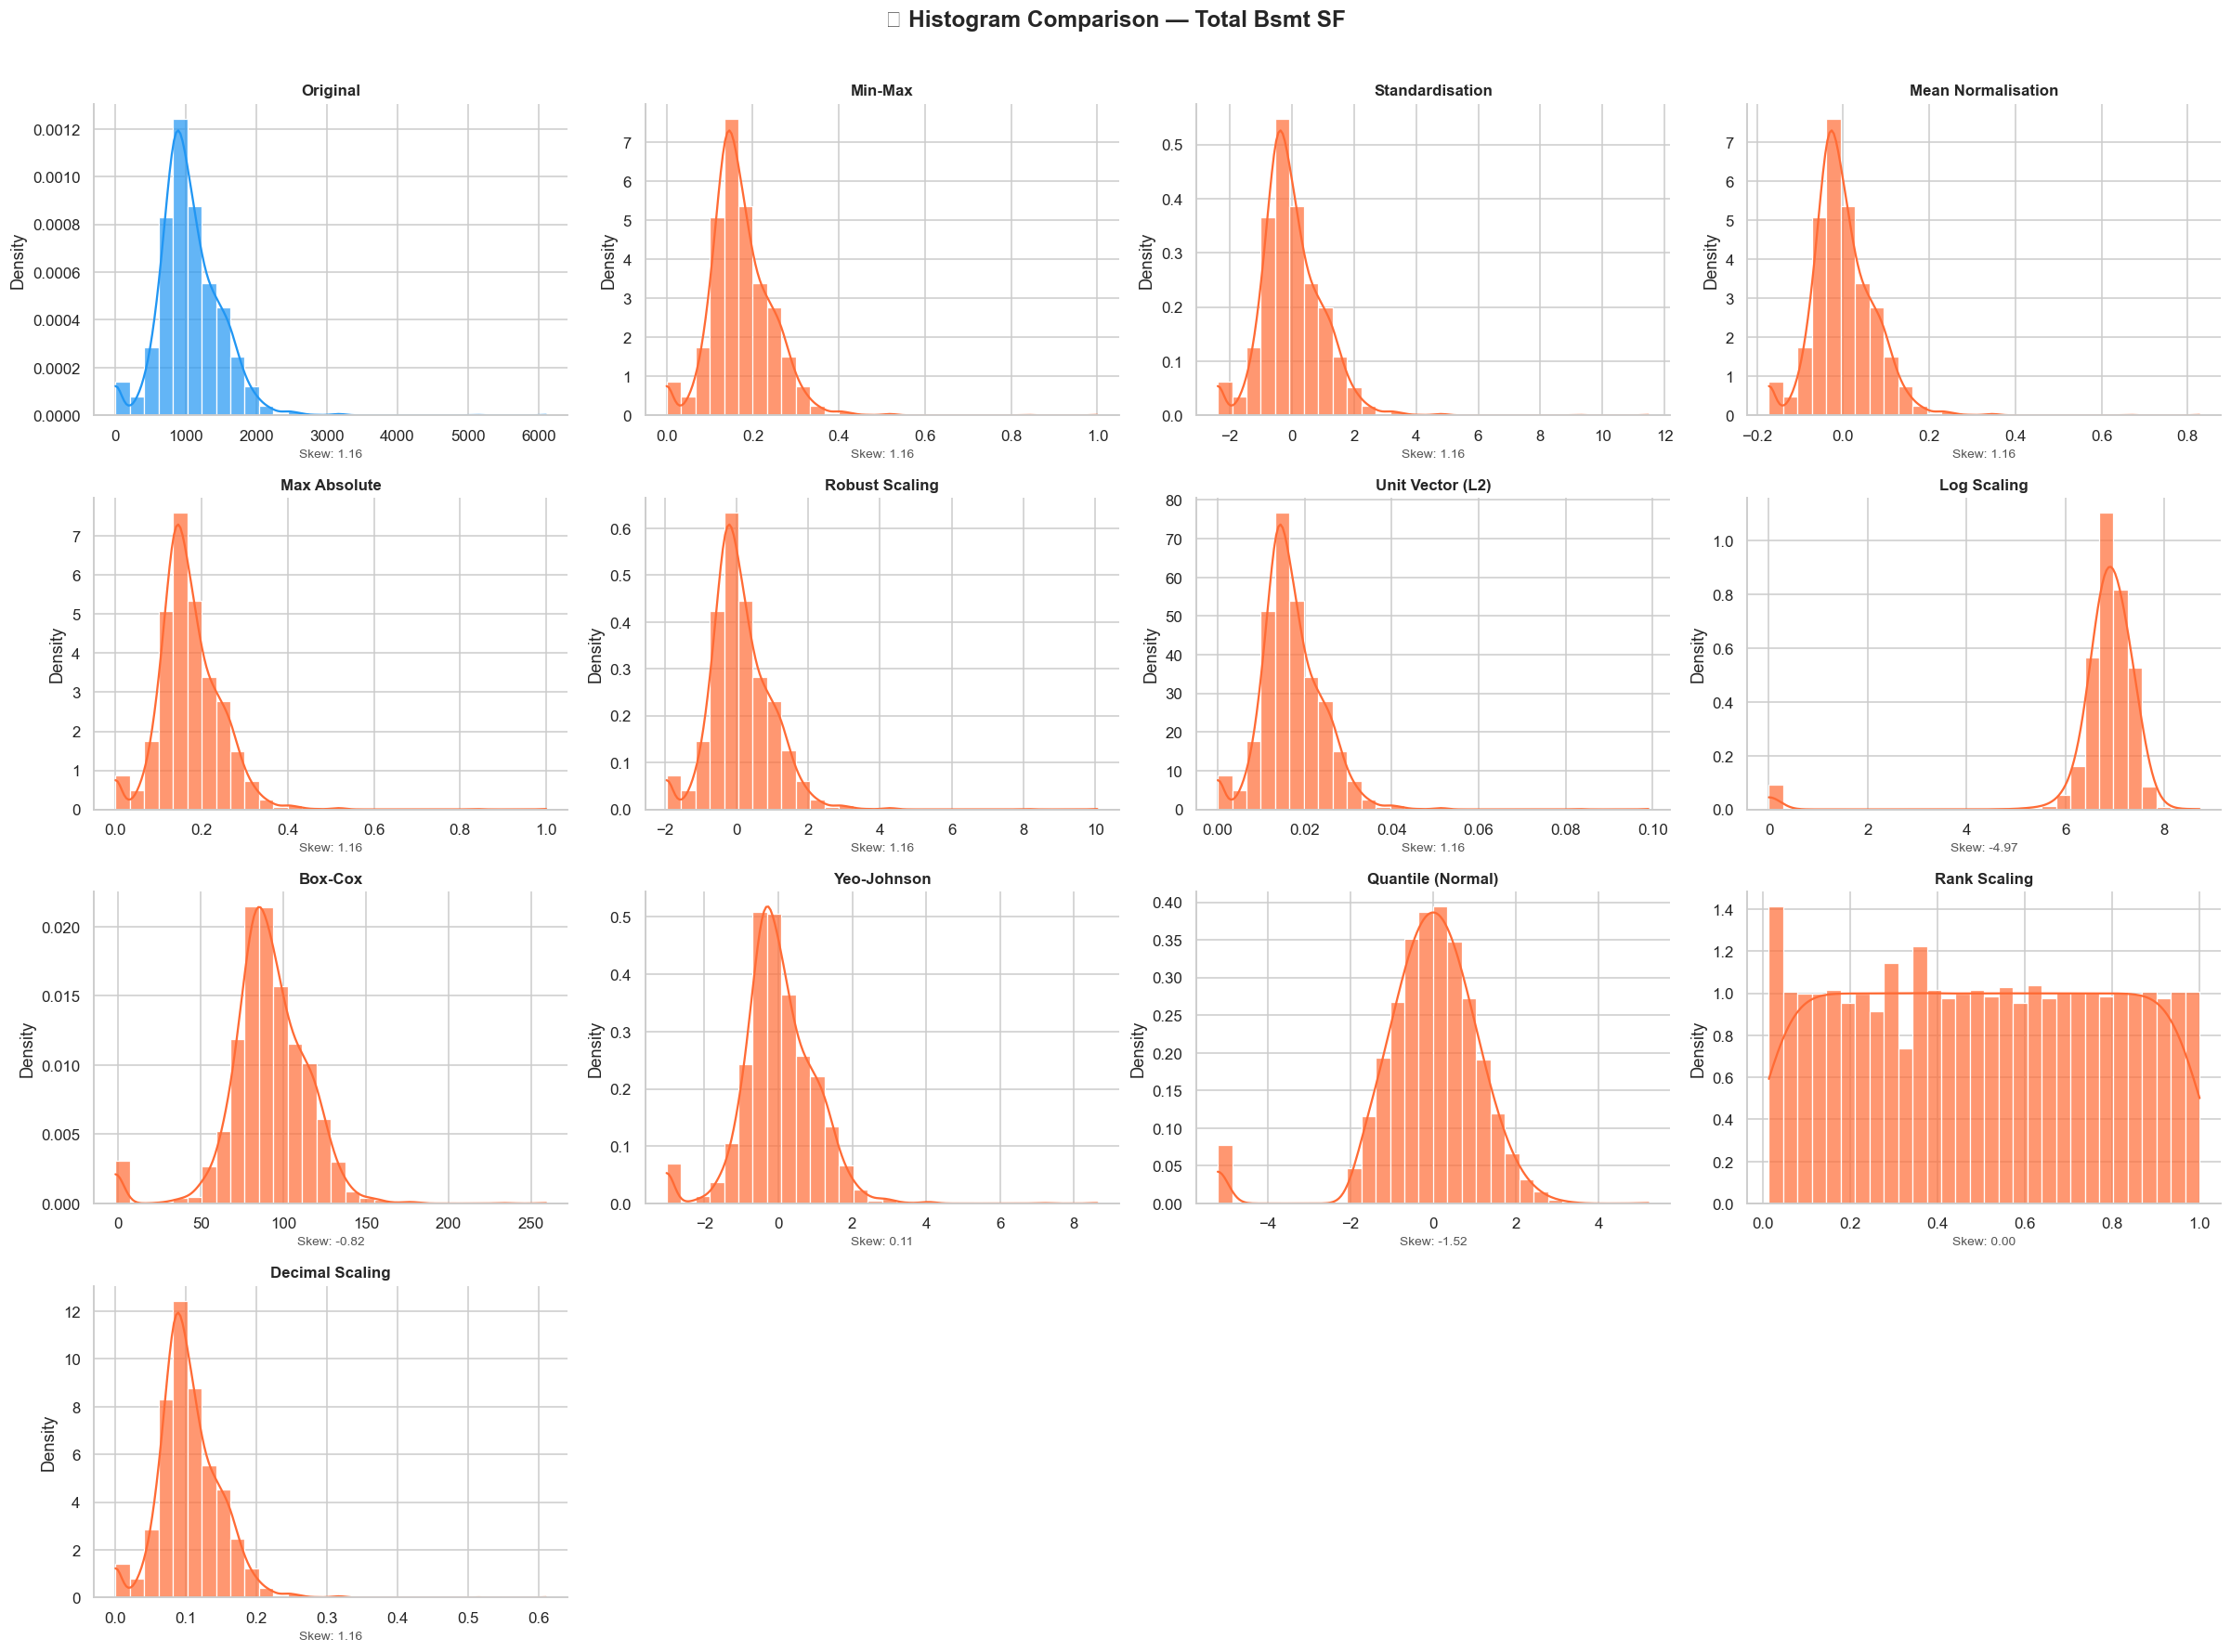

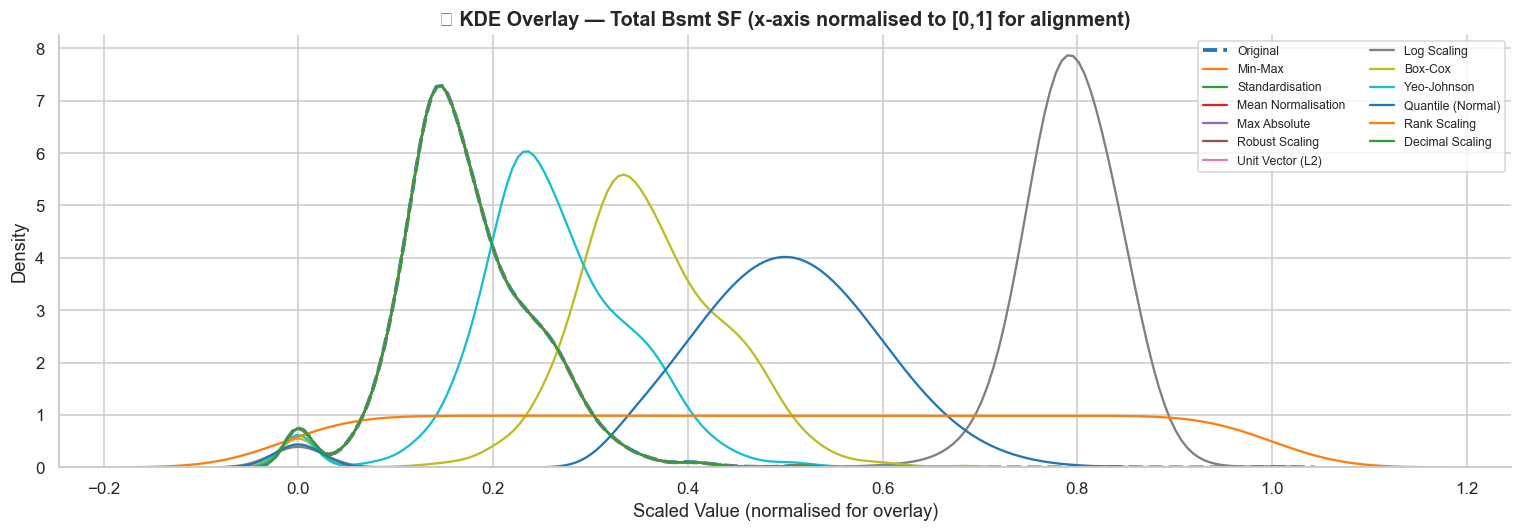

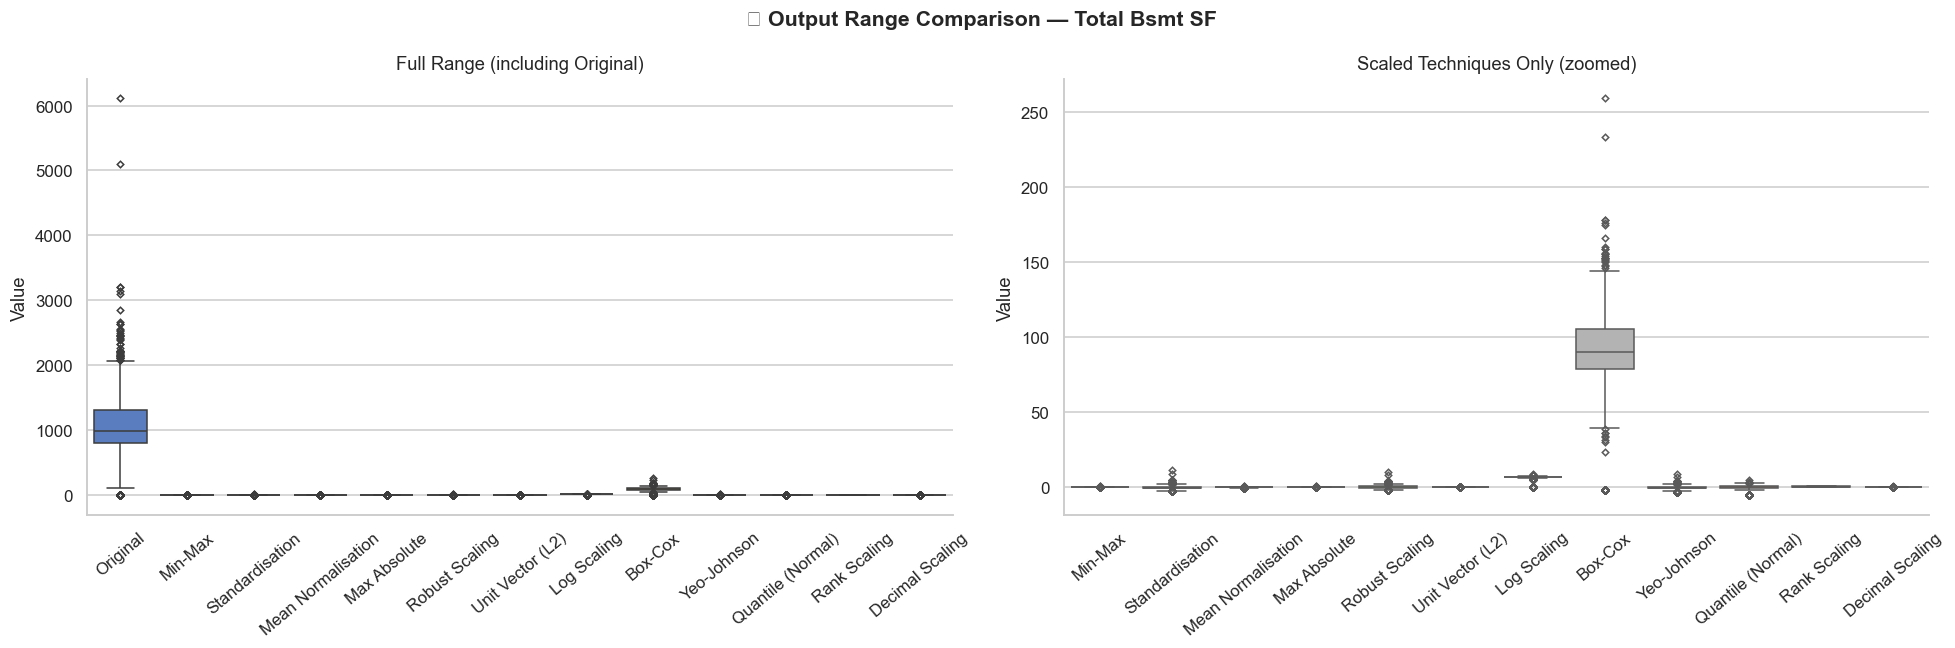

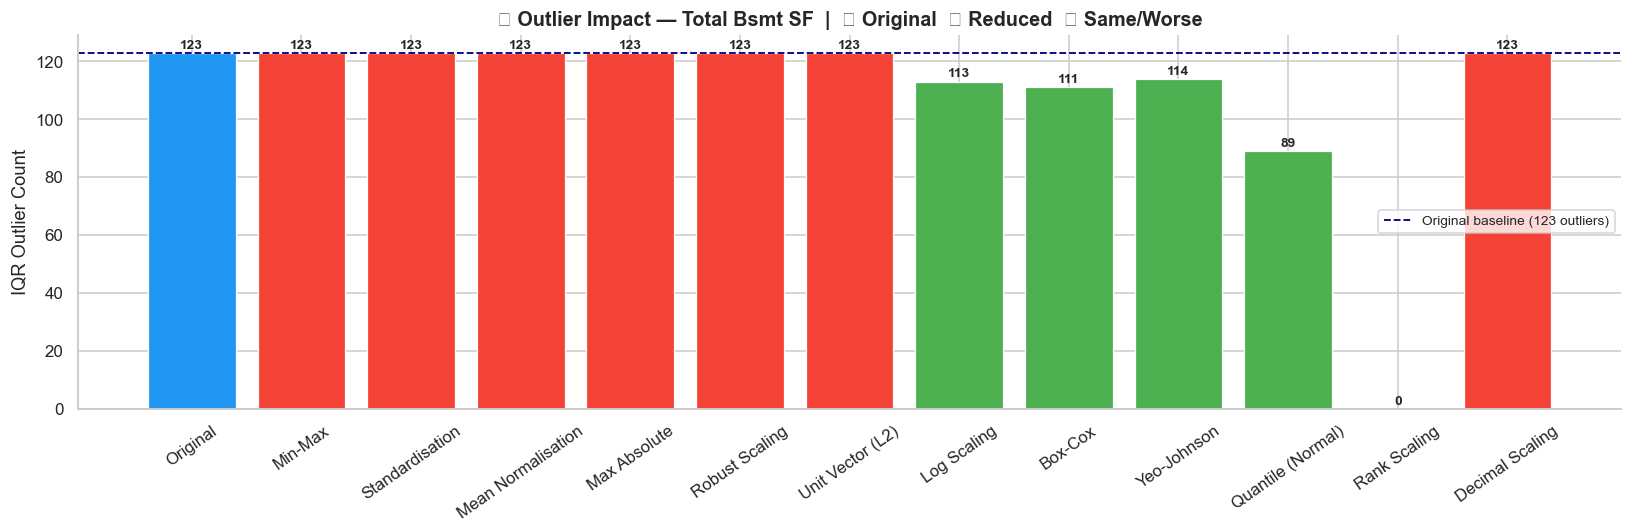

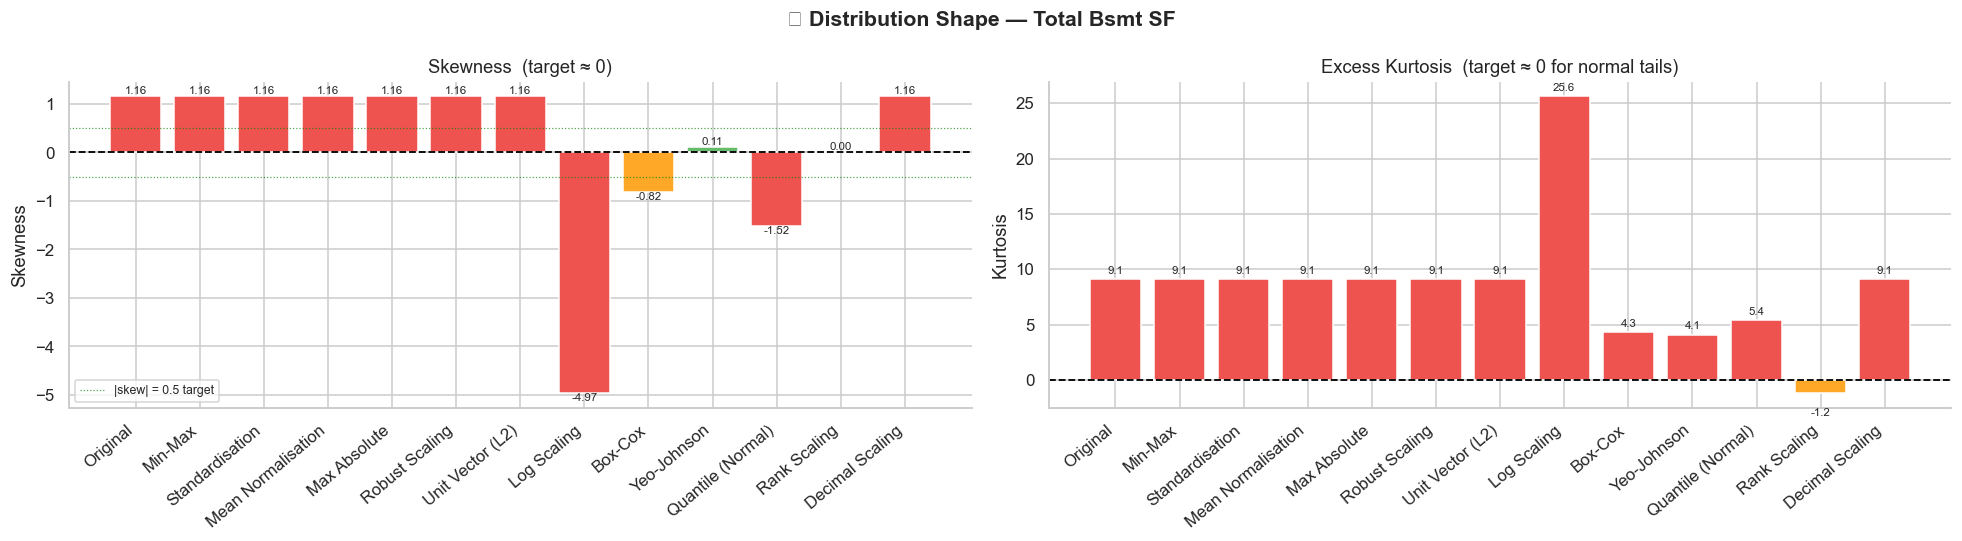

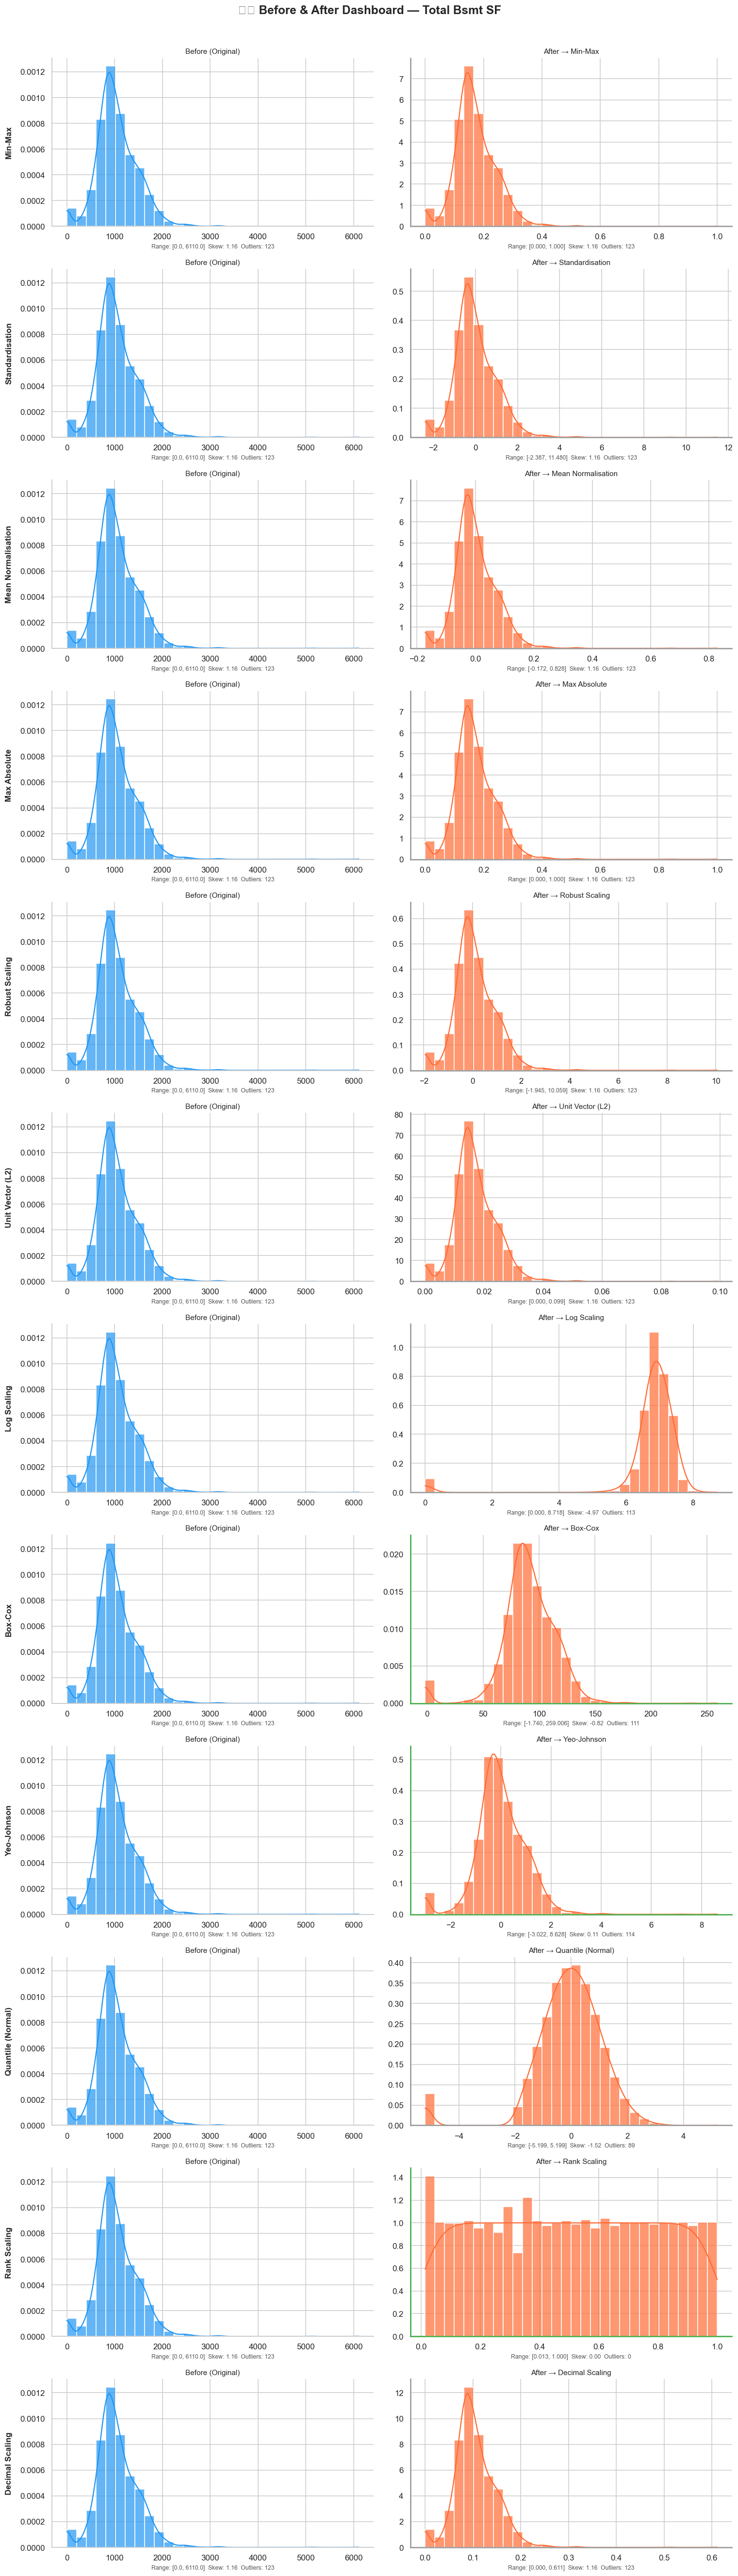

Legend: 🟢 green border = skewness improved vs original


In [15]:
# Run analysis for Total Bsmt SF
scaled_bsmt = run_full_analysis(data, 'Total Bsmt SF')


  Feature: Garage Area


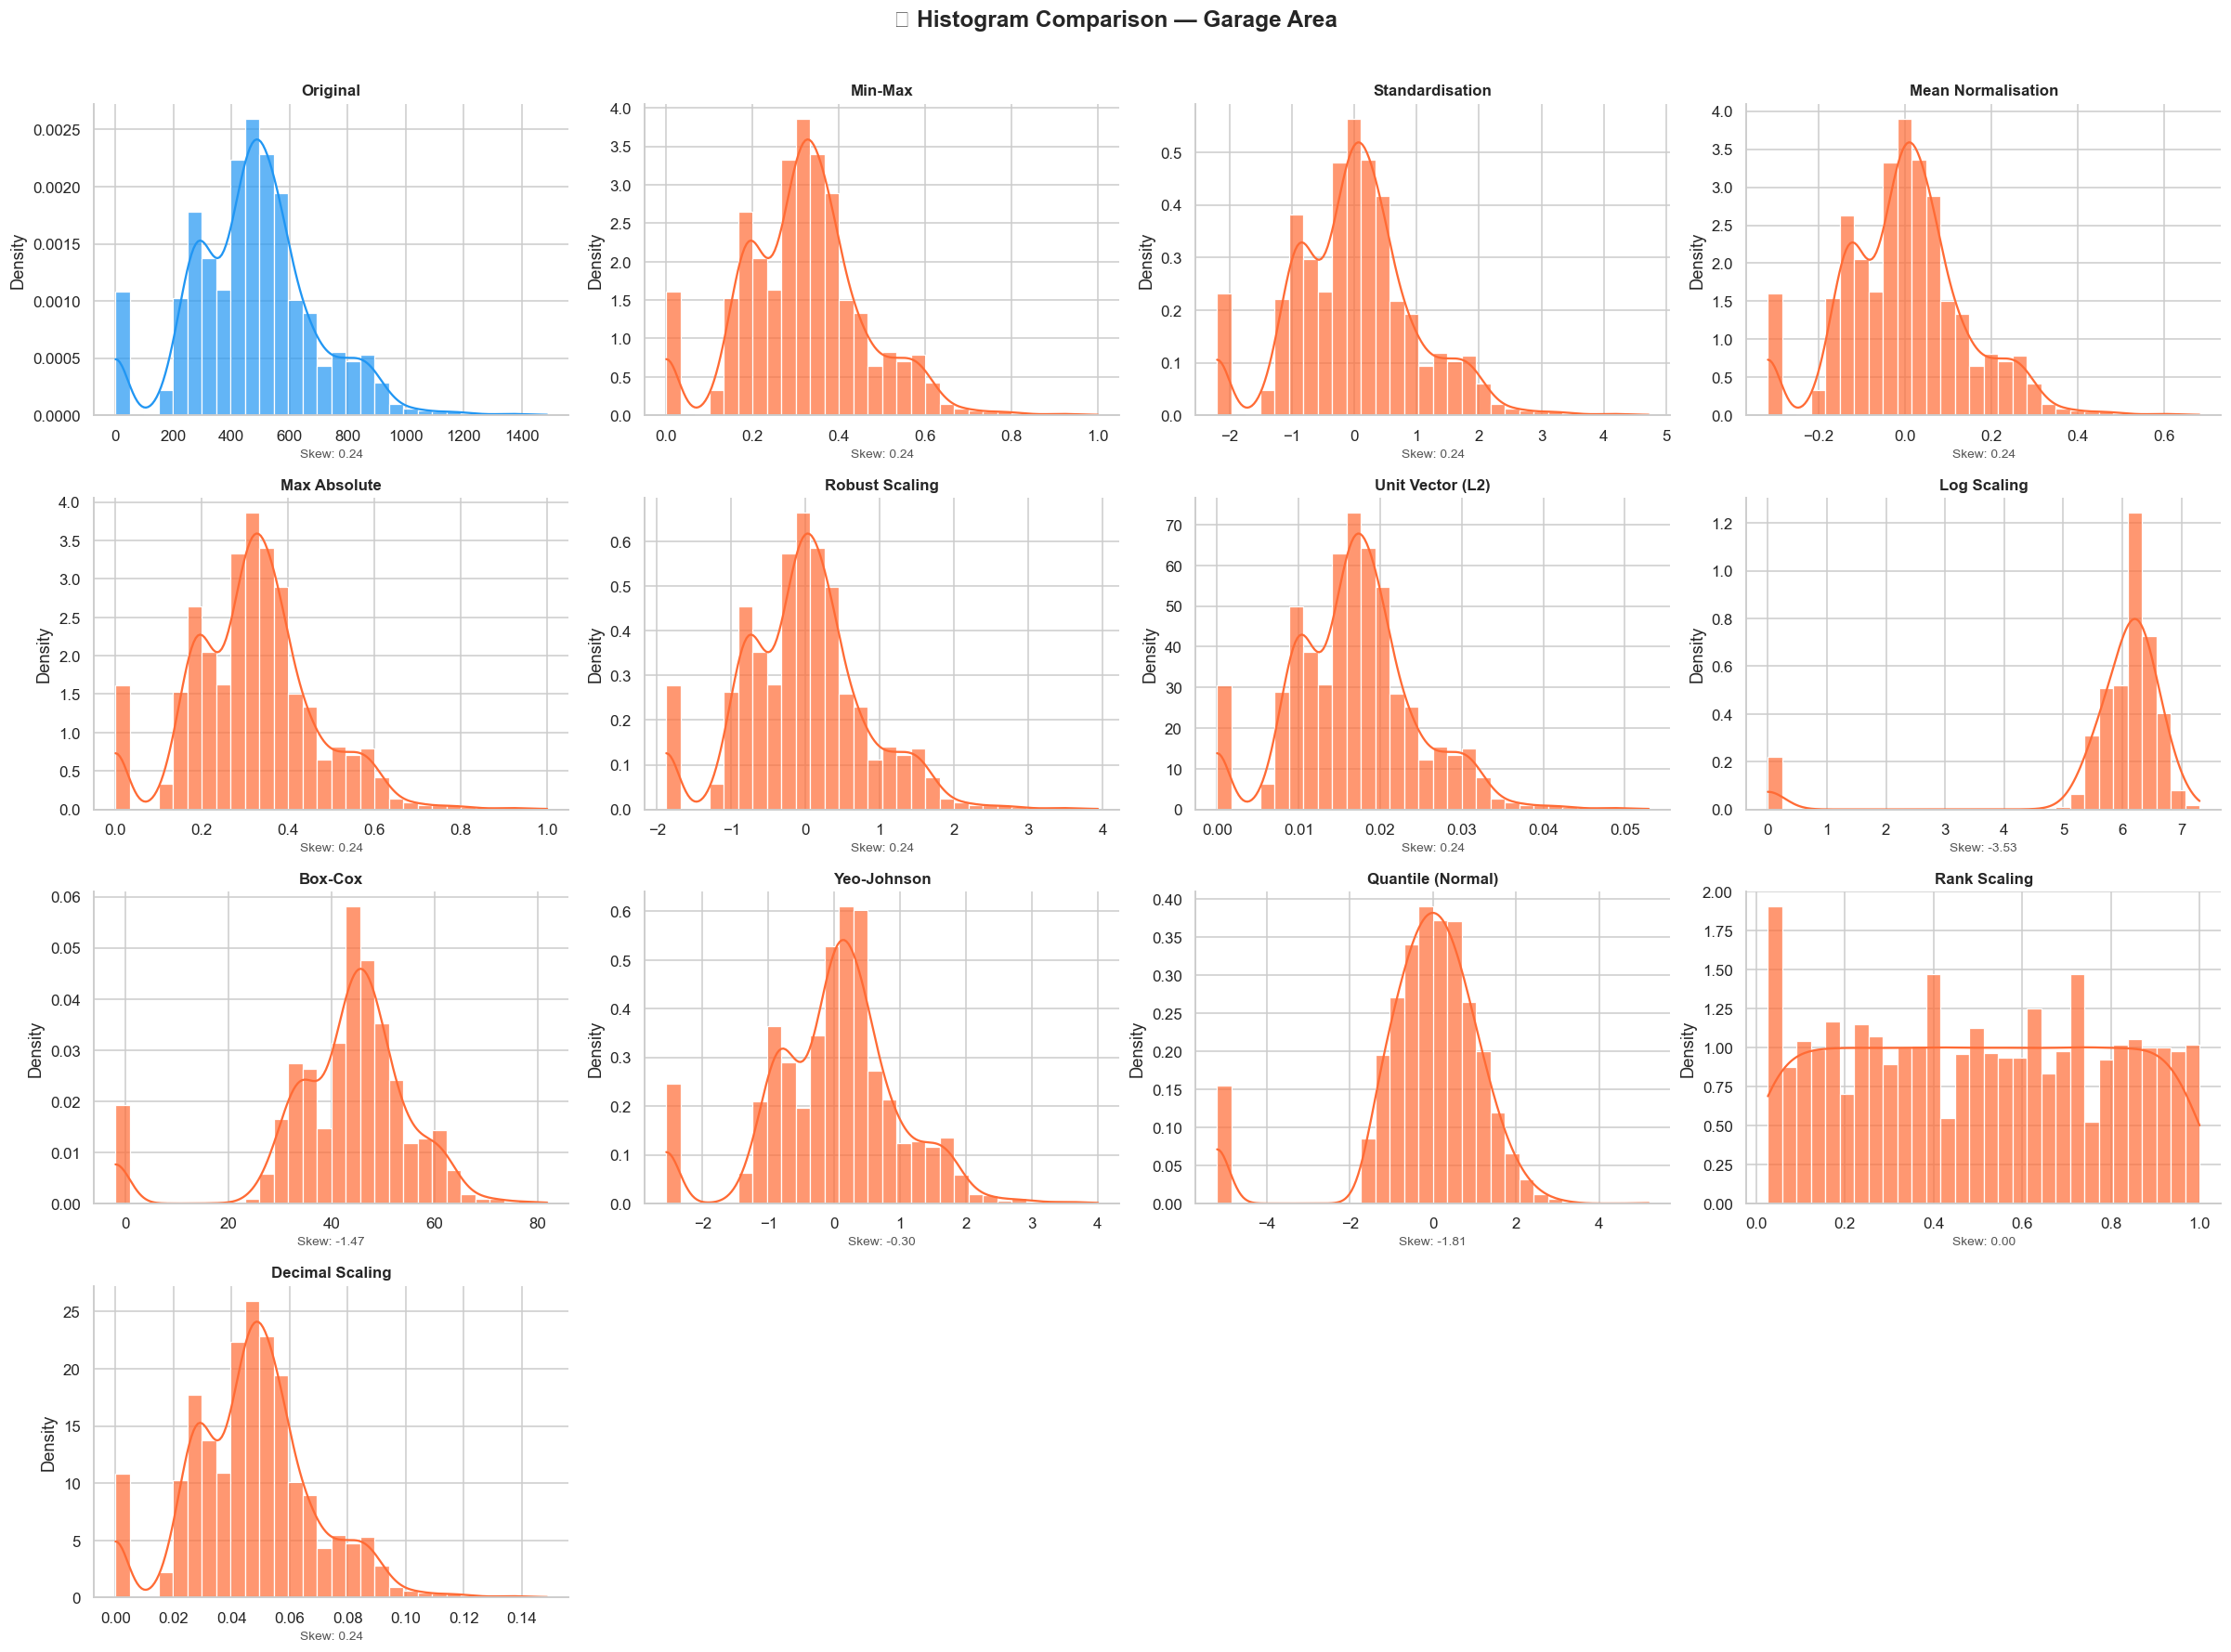

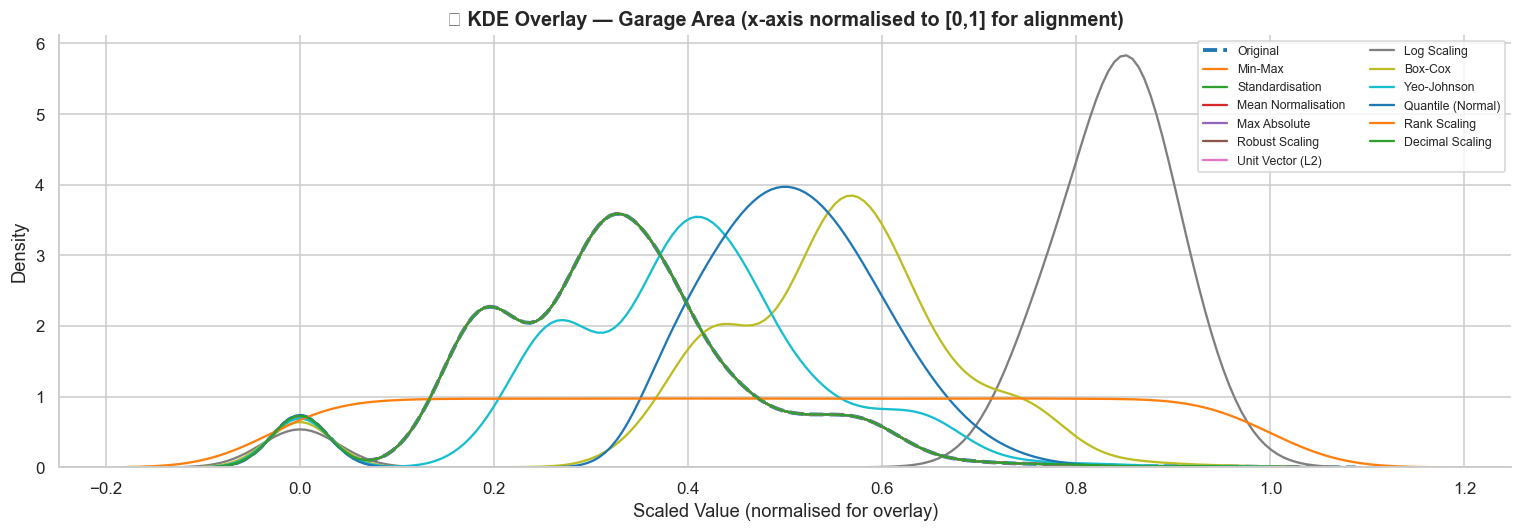

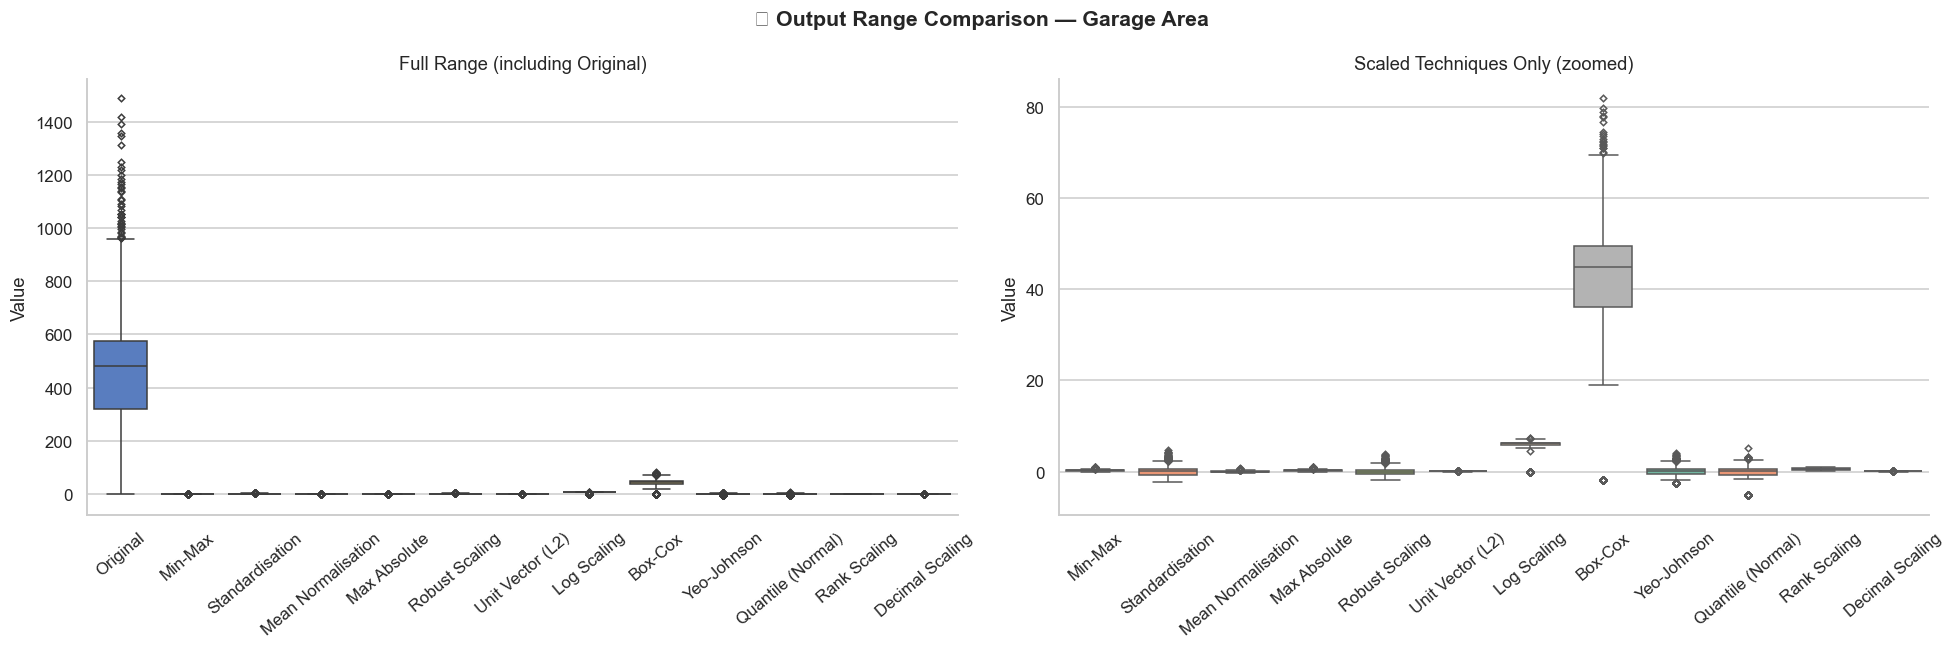

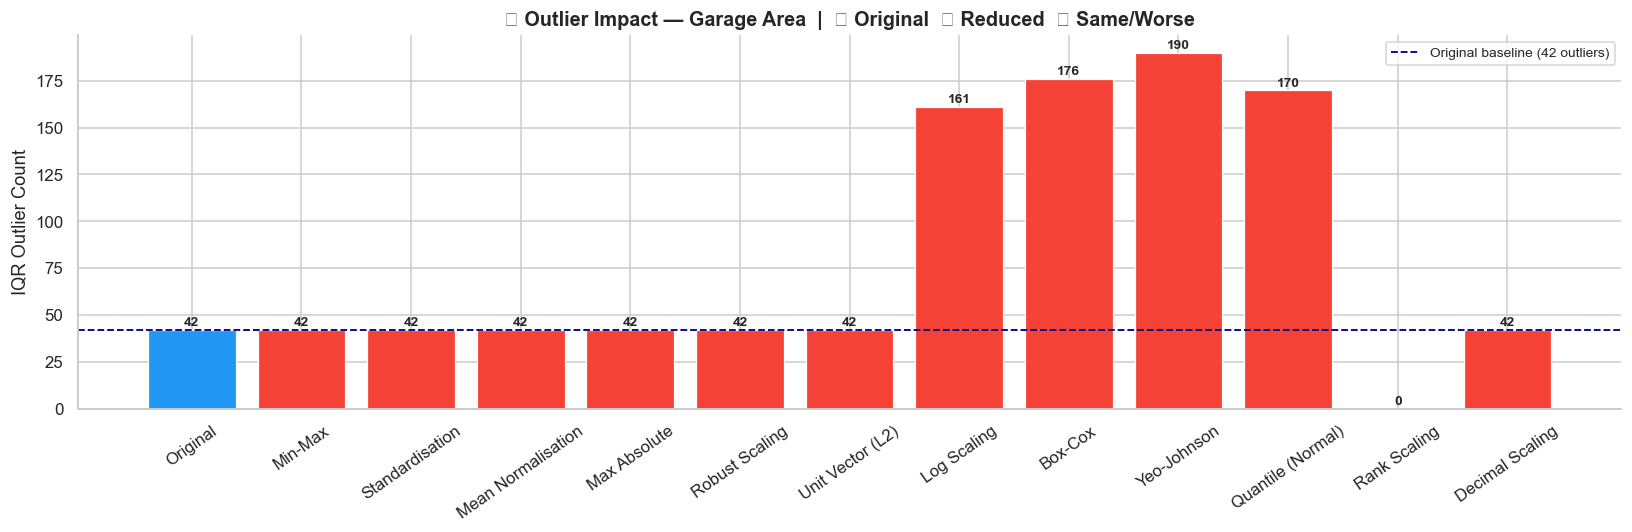

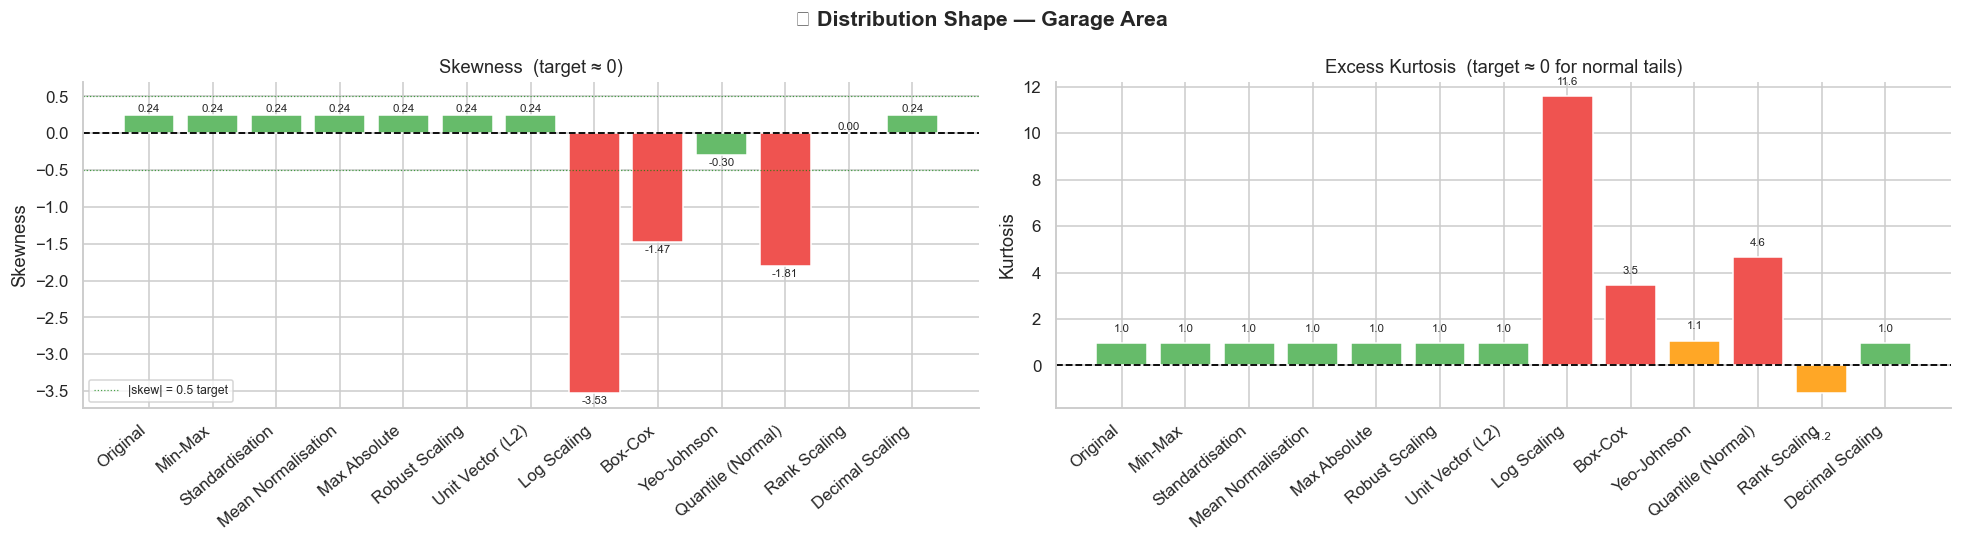

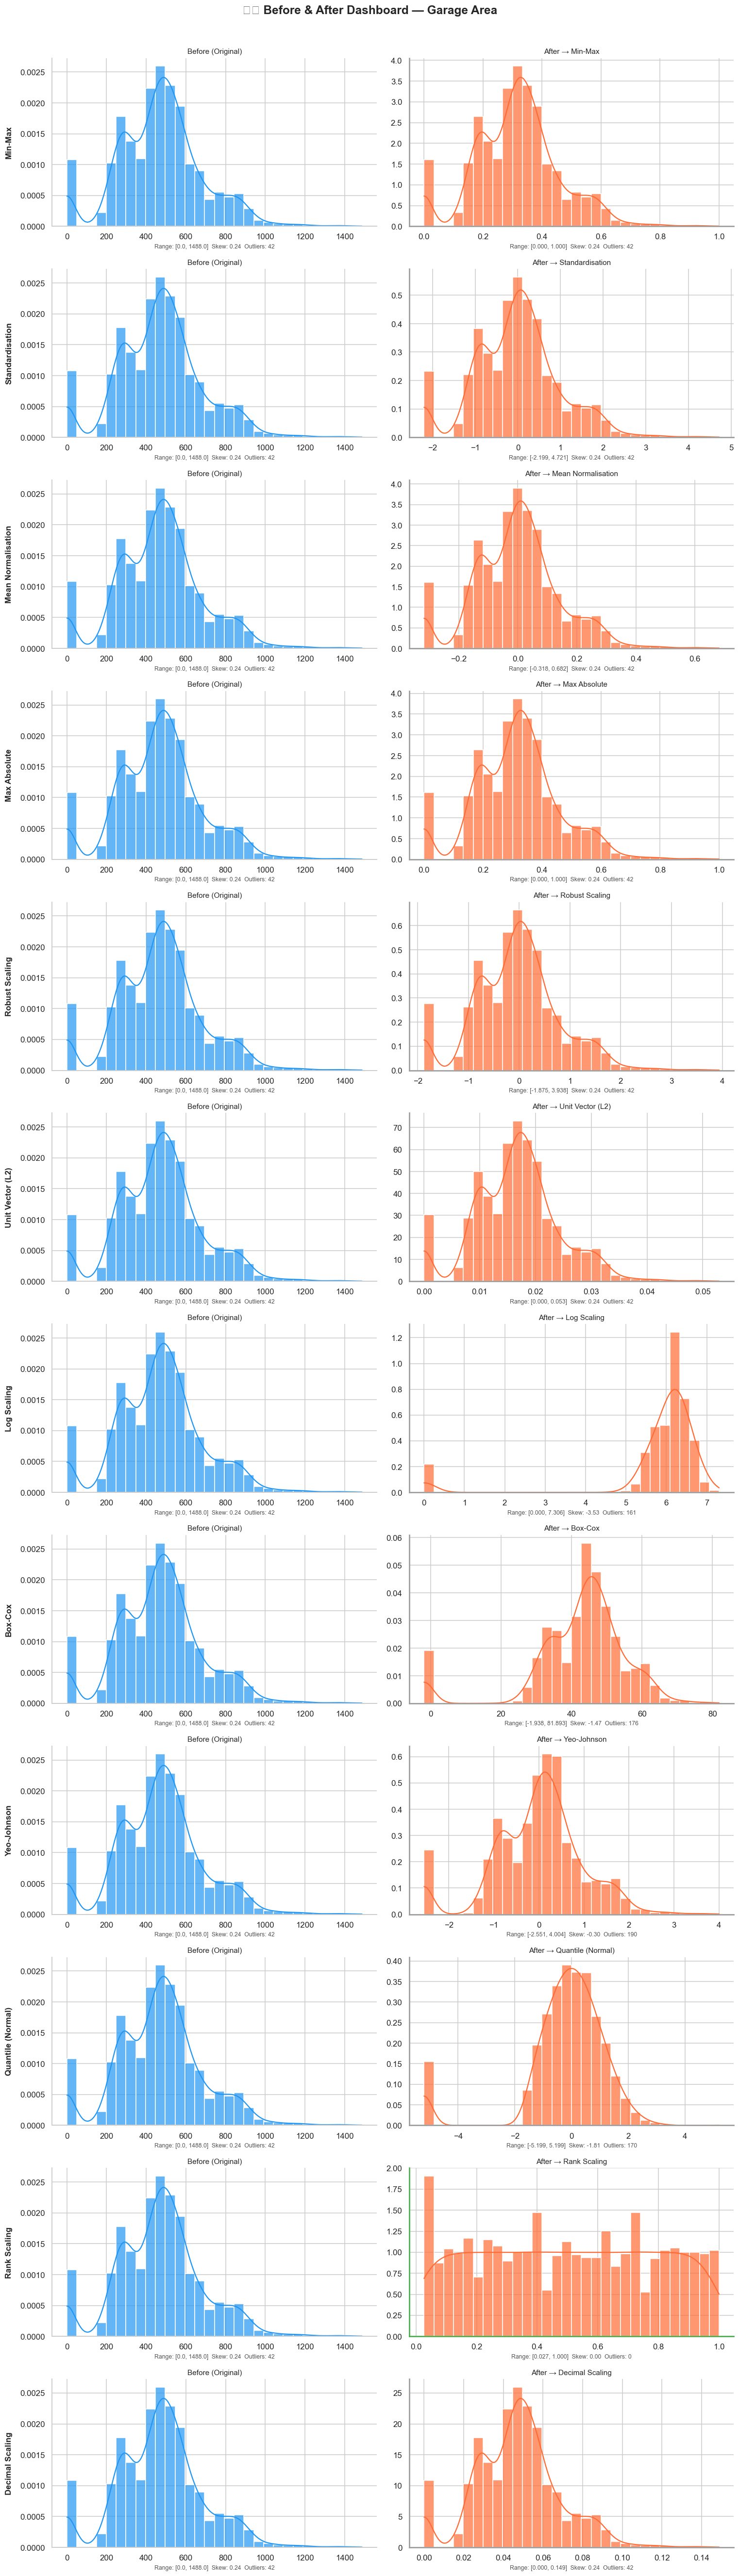

Legend: 🟢 green border = skewness improved vs original


In [16]:
# Run analysis for Garage Area
scaled_garage = run_full_analysis(data, 'Garage Area')

---
## 7. 📋 Statistical Summary Table

All techniques × all features in one consolidated table for easy comparison.

In [17]:
# Build a master summary dataframe across all features and all scalers
all_scaled = {
    'SalePrice':     scaled_saleprice,
    'Gr Liv Area':   scaled_grliv,
    'Lot Area':      scaled_lot,
    'Total Bsmt SF': scaled_bsmt,
    'Garage Area':   scaled_garage,
}

summary_records = []

for feature, scaled in all_scaled.items():
    for scaler_name, vals in scaled.items():
        row = {'Feature': feature, 'Scaler': scaler_name}
        row.update(compute_stats(pd.Series(vals)))
        summary_records.append(row)

summary_df = (
    pd.DataFrame(summary_records)
    .set_index(['Feature', 'Scaler'])
    .round(4)
)

# Preview: SalePrice slice
print("=== Summary: SalePrice ===")
summary_df.loc['SalePrice']

=== Summary: SalePrice ===


,Min,Max,Mean,Std,Skewness,Kurtosis,IQR Outliers
Scaler,,,,,,,
Original,12789.0000,755000.0000,180841.0338,79889.9044,1.744,5.118,137
Min-Max,0.0000,1.0000,0.2264,0.1076,1.744,5.118,137
Standardisation,-2.1039,7.1881,-0.0000,1.0002,1.744,5.118,137
Mean Normalisation,-0.2264,0.7736,-0.0000,0.1076,1.744,5.118,137
Max Absolute,0.0169,1.0000,0.2395,0.1058,1.744,5.118,137
Robust Scaling,-1.7525,7.0833,0.2481,0.9511,1.744,5.118,137
Unit Vector (L2),0.0012,0.0706,0.0169,0.0075,1.744,5.118,137
Log Scaling,9.4564,13.5345,12.0213,0.4075,-0.015,1.517,60
Box-Cox,9.8075,14.2615,12.5933,0.4468,0.002,1.480,59


In [18]:
# Highlight the best scaler per feature (lowest |skewness|)
best_scaler = (
    summary_df
    .reset_index()
    .assign(AbsSkew=lambda df: df['Skewness'].abs())
    .sort_values('AbsSkew')
    .groupby('Feature')
    .first()
    [['Scaler', 'Skewness', 'IQR Outliers']]
    .rename(columns={'Skewness': 'Best Skewness', 'IQR Outliers': 'Outliers After'})
)

print("=== Best Scaler per Feature (by lowest |skewness|) ===")
best_scaler

=== Best Scaler per Feature (by lowest |skewness|) ===


,Scaler,Best Skewness,Outliers After
Feature,,,
Garage Area,Rank Scaling,0.001,0
Gr Liv Area,Yeo-Johnson,-0.000,23
Lot Area,Rank Scaling,0.000,0
SalePrice,Rank Scaling,0.000,0
Total Bsmt SF,Rank Scaling,0.000,0


---
## 8. 🧭 Choosing the Right Scaler

Use this decision tree as your starting point:

```
Does your algorithm require bounded input (e.g. neural networks, image pixels)?
└── Yes → Min-Max Scaling  (but beware of outliers compressing the range)

Does your algorithm assume Gaussian input (e.g. Linear/Logistic Regression, PCA)?
└── Yes → Standardisation  (most common default choice)

Does your data have significant outliers?
├── Mild outliers     → Robust Scaling  (uses median + IQR)
└── Severe outliers   → Quantile or Rank Scaling

Is the data right-skewed AND you need to fix the shape?
├── Strictly positive → Box-Cox or Log Scaling
└── Zeros/negatives   → Yeo-Johnson

Do you need to preserve sparse data (many zeros)?
└── Yes → Max Absolute Scaling  (does not shift data)

Does relative order matter more than magnitude?
└── Yes → Rank Scaling
```

### ✅ Validation Checklist After Scaling

1. **Does the output range match the algorithm's requirement?**  
   (e.g. [0,1] for sigmoid activation, ~N(0,1) for PCA)
2. **Is skewness closer to 0?** (target: |skew| < 0.5 for shape-sensitive models)
3. **Did outliers reduce or at least stay the same?**
4. **Did you apply the same fitted scaler to train AND test sets?**  
   (Always fit on train, transform both — never fit on test data)

---

## ⚠️ Common Mistakes

| Mistake | Why It's a Problem |
|---|---|
| Scaling before train/test split | Test data leaks into the scaler's fit → data leakage |
| Using Min-Max with outliers | One extreme value compresses everything else |
| Applying scaling to target variable | Generally not needed; can hurt interpretability |
| Scaling categorical variables | Scaling applies to numerical features only |
| Forgetting to inverse_transform | Predictions in wrong units if target was scaled |

---

## 🔁 Where Scaling Fits in the ML Pipeline

```
Raw Data
  → Handle Missing Values
  → Encode Categoricals
  → Feature Transformation  (fix skewness / shape)
  → Feature Scaling         ← you are here
  → Train / Test Split      (or split before, fit scaler on train only)
  → Model Training
```

---

*Notebook by [Your Name] · [GitHub Profile Link]*  
*Dataset: [Ames Housing Dataset on Kaggle](https://www.kaggle.com/datasets/prevek18/ames-housing-dataset)*  
*See also: [Feature_Transformation.ipynb](./Feature_Transformation.ipynb) — the companion notebook on distribution transformation*
